# Turbulent flux response to a longwave radiative forcing

The sensible heat flux is not independent of the radiation field. It is a bulk
flux driven by the skin-to-air temperature difference,

$$SH_{up} \;\approx\; \rho\, c_p\, C_H\, U \,(T_{skin} - T_{2m})$$

so lowering the downwelling longwave over a surface with little heat capacity
cools the skin, shrinks $(T_{skin} - T_{2m})$, and weakens the turbulent flux
that had been carrying heat away. The turbulent term therefore **damps** the
longwave forcing: it gives back part of what the radiation took. *How much* it
gives back is a property of the surface, because the skin temperature's freedom
to move is a property of the surface.

## Sign convention — read this before interpreting any number

Every ERA5 surface flux here is stored **positive downward, into the surface**:

| `msshf` | meaning |
|---|---|
| $> 0$ | heat flowing from the air **into** the surface |
| $< 0$ | heat flowing from the surface **into** the air (upward SH) |

Under liquid-bearing overcast on the Barrow strip $T_{skin}$ exceeds $T_{2m}$
most of the time, so `msshf` is typically **negative** there — the flux is
carrying heat *up*, out of the surface. A DLR decrease then cools the skin,
shrinks the skin-to-air difference, and makes `msshf` *less* negative: the
upward flux weakens, less heat leaves the surface, and the cooling is damped.

Over pack ice in midwinter the sign often reverses ($T_{skin} < T_{2m}$ under
the surface inversion, `msshf` $> 0$), and there the same DLR decrease
*strengthens* a downward flux. **Both are damping.** The sign of the flux is not
the sign of the feedback, which is why nothing below averages the two regimes
together.

## The important caveat

Nothing here is a controlled forcing experiment. Every slope is a **covariance
across the natural synoptic variability of the record**: hours with high DLR are
cloudy, and cloudy hours also differ in wind speed, air mass origin, and
boundary-layer stability. Read the numbers as *how the surface state co-varies
with DLR*. Two estimators are reported throughout and they bracket the causal
answer from opposite sides — see the "Two estimators" section below.

## What this notebook contains

| Cell | Figure |
|---|---|
| Load | one streaming pass; everything below is drawn from it |
| Report | the numbers the figures draw |
| 1 | LWP against SHF, density-coloured, per surface class, with a linear fit |
| 2 | DLR against SHF, same treatment |
| 3 | $(T_{skin}-T_{2m})$ against SHF — the bulk relation itself |
| 4 | the partition of $d(LWD)$ by surface class |
| 5 | the marginal ice zone as a natural experiment |
| 6 | SHF stratified by LWP regime and surface type — the matched comparison |
| 7 | DLR against LWP, against the ARM observations at Barrow |
| 8 | DLR against the LATENT heat flux |
| 9 | d(SHF)/d(DLR) and d(LHF)/d(DLR) by surface type, with bootstrap intervals |
| 10 | how each slope moves as confounders are added — the control ladder |

All analysis lives in `turbulent_flux_response.py`; this notebook holds none of
its own, so the two cannot drift apart. Editing the module and re-running a
figure cell picks up the change (autoreload is on).

---

## What a regression is doing here, and why

*This section assumes no background beyond a first course in calculus. If you
already think in terms of partial derivatives estimated from covariances, skip
to "Setup".*

### The problem: a derivative you cannot take analytically

The question this notebook asks is

$$\frac{\partial (\text{sensible heat flux})}{\partial (\text{downwelling longwave})}$$

— if the downwelling longwave radiation (DLR) reaching the Arctic surface goes
up by one watt per square metre, how many watts per square metre does the
turbulent heat flux change by?

You cannot get this by differentiating a formula. The chain runs DLR → skin
temperature → skin-to-air temperature difference → turbulent flux, and each
link involves the surface's heat capacity, the boundary-layer stability, the
wind, and the sea ice state. There is no closed-form expression to
differentiate. What there *is* is 14 million hours of ERA5 in which DLR and the
turbulent flux both vary, and the derivative is recoverable from how they vary
*together*.

### The method: a slope is an estimated derivative

Ordinary least squares fits the straight line

$$y = a + b\,x$$

that minimises the sum of squared vertical distances from the data to the line.
The fitted slope has a closed form,

$$b = \frac{\mathrm{cov}(x, y)}{\mathrm{var}(x)},$$

and this is the whole idea: **$b$ is an estimate of $dy/dx$ averaged over the
range of $x$ the data actually cover.** Where the relation really is a straight
line, $b$ *is* the derivative. Where it bends, $b$ is the best single-number
summary of it over that range — which is why this notebook draws the binned
means alongside the fits, so you can see where the straight line is
misrepresenting a curve.

Two properties make this practical at scale. First, $b$ depends on the data
only through **sums**: $\sum x$, $\sum y$, $\sum x^2$, $\sum xy$ and the
count. Those can be accumulated one block at a time, so the derivative is
computed exactly on all 14 million samples without ever holding them in memory
— which is what `new_moments` and `accumulate_moments` do here. Second, the
operator is **linear**: the slope of a sum is the sum of the slopes. That is
what makes the energy partition in figure 4 an exact identity rather than an
approximate one.

### How well does the line describe the cloud? $r^2$

$$r^2 = \frac{\mathrm{cov}(x,y)^2}{\mathrm{var}(x)\,\mathrm{var}(y)}$$

is the fraction of the variance in $y$ that the fitted line accounts for.
$r^2 = 1$ is a perfect line; $r^2 = 0$ is no linear relation at all.

**A low $r^2$ does not mean the slope is wrong or the effect is absent.** It
means one straight line through this particular population leaves most of the
scatter unexplained — usually because something else is also varying. That is a
statement about the population, not about the physics, and the fix is to
control for the something else (below), not to discard the slope.

### Which variable goes on which side — this is not cosmetic

There are two least-squares fits of any pair, and **they are different
estimators**:

$$\mathrm{slope}(y|x) = \frac{\mathrm{cov}}{\mathrm{var}_x},
\qquad
\mathrm{slope}(x|y) = \frac{\mathrm{cov}}{\mathrm{var}_y},
\qquad
\mathrm{slope}(y|x)\cdot\mathrm{slope}(x|y) = r^2.$$

So $1/\mathrm{slope}(y|x) = \mathrm{slope}(x|y)/r^2$: **inverting the wrong
fit inflates the answer by $1/r^2$**, and the error is largest exactly where
the data are noisiest. Put the quantity you are treating as the *response* on
the left. To get $d(\mathrm{SHF})/d(\mathrm{DLR})$, regress SHF on DLR — not
DLR on SHF, and not the reciprocal of that. In this notebook the sea-ice fit of
DLR against SHF has $r^2 = 0.025$, so inverting it would overstate
$d(\mathrm{SHF})/d(\mathrm{DLR})$ by a factor of forty.

### Confounding, and the two standard fixes

An hour with high DLR is a cloudy hour, and an Arctic cloudy hour is usually a
warm, moist, windy one. So a plain slope of SHF against DLR charges the
radiation for everything else the weather brought with it. Two remedies, both
used here:

1. **Add the confounder to the regression** (multiple regression). Fit
   $y = a + b\,x_1 + c\,x_2$ and read $b$: the response to $x_1$ *holding
   $x_2$ fixed*. That is a genuine partial derivative,
   $\left.\partial y/\partial x_1\right|_{x_2}$. `control="t2m"` does this
   with the 2 m air temperature.
2. **Stratify** — split the data into bins within which the confounder barely
   varies, and compare inside a bin. Figure 6 does this with LWP regime and
   surface class.

Both appear in the reference below. Neither turns a correlation into causation:
they remove the confounders you named, not the ones you did not.

### What this is not

Every number here is a **covariance across the natural variability of the
record**, not a controlled experiment. Nobody turned DLR up by one watt and
measured what happened. Where two estimators disagree — plain versus
controlled — the truth is usually bracketed between them, and this notebook
reports both rather than picking one.

Confidence intervals *are* quoted, but **not** from the textbook standard error
— that formula assumes independent samples and would be wrong here by a factor
of order a hundred. They come from a moving-block bootstrap instead; the
section "How can ERA5 have a confidence interval at all?" below explains why
that works when the naive formula does not.

### How can ERA5 have a confidence interval at all?

This deserves care, because the obvious objection is a good one: **ERA5 is not
a set of independent draws of nature.** Reading the same file twice gives the
same number. There is no measurement noise to average down. So what could an
interval possibly be measuring?

**What we are actually uncertain about.** Not the value ERA5 stores — that is
exact. What is uncertain is whether the *slope we fitted* is a property of the
climate or an accident of the particular weather that happened. Winter
2024/2025 delivered one specific sequence of storms, clear spells and ice-edge
positions. The same climate could have delivered a different sequence. The
question the interval answers is:

> If the atmosphere had thrown a **different but equally plausible sequence of
> weather systems** at this domain, how different would the fitted slope have
> been?

That is a genuine sampling distribution, and the record does contain repeated
draws from it — just far fewer than it contains cell-hours.

**The unit of independent information is a weather system, not a cell-hour.**
Measured on the Barrow strip, Oct 2024 – Mar 2025:

| | |
|---|---|
| lag-1 hourly autocorrelation, DLR | 0.988 |
| lag-1 hourly autocorrelation, SHF | 0.984 |
| implied decorrelation time | ~72 h |
| DLR correlation at 50 km separation | 0.99 |
| DLR correlation at 600 km separation | 0.65 |

Two adjacent grid cells in the same storm tell you almost the same thing; so do
two hours an hour apart. The strip is ~1100 × 550 km — **one weather system
wide** — so its 2,501 cells carry on the order of one to three independent
pieces of information at any instant, not 2,501. A season of 4,368 hours is
about **60 independent synoptic situations**, not 10.9 million independent
samples.

This is exactly why the textbook formula fails: it divides by $\sqrt{n}$ with
$n$ = cell-hours. It is too small by roughly $\sqrt{n/n_{\mathrm{eff}}}$,
which here is a factor of order 100.

**The fix: resample the units that really are near-independent.** A moving-block
bootstrap:

1. **Cut** the record into contiguous blocks of time longer than the
   decorrelation time. Each block holds one or two synoptic situations.
2. **Draw** blocks at random *with replacement* until a synthetic record of the
   original length is assembled. Each synthetic record is a plausible
   alternative answer to "which weather happened, in which order".
3. **Refit** the slope on each synthetic record. The spread of slopes across
   2,000 synthetic records *is* the sampling distribution; its 2.5th and 97.5th
   percentiles are the 95% interval.

Nothing is assumed about the shape of the distribution — it is built
empirically from the data.

**Why blocks, and not individual points.** Resampling cell-hours one at a time
would shatter the correlation structure and hand back the same too-narrow
answer as the naive formula. Keeping a block contiguous preserves the
correlation *within* a weather system, so each block contributes one system's
worth of information — the correct quantum.

**Why the spatial correlation needs no separate treatment.** A block is a slab
of *time* containing the entire spatial field. Whatever correlation exists
between grid cells rides along inside the block, untouched. The resampling only
shuffles along the time axis — the one axis on which the record genuinely
supplies repeated, near-independent draws. So the spatial degrees of freedom
never have to be estimated, which is fortunate, because on this domain they are
hard to pin down.

**Choosing the block length.** It must exceed the decorrelation time (~3 days)
so blocks are near-independent, but stay short enough to leave many blocks.
The diagnostic is convergence — lengthen the block and the interval widens
until the blocks really are independent, then stops:

| block length | bootstrap SE | 95% CI |
|---|---|---|
| 3 days | 0.0256 | [+0.0008, +0.1011] |
| 7 days | 0.0285 | [−0.0022, +0.1064] |
| 14 days | 0.0299 | [−0.0094, +0.1069] |

(sea ice $d\mathrm{SHF}/d\mathrm{DLR}$, one season; the naive SE for the same
slope is **0.00020**.) Converged by about a week, which is why the default is 7
days. Note what the honest interval does to the claim: the naive one pins the
slope to four significant figures, while the bootstrap cannot distinguish it
from zero on a single season.

**Why this is cheap.** The moments are additive, so the per-block moment
matrices are accumulated in the *same* streaming pass as everything else, and a
bootstrap replicate is just a weighted sum of block matrices — no re-reading
the archive, no refitting from raw samples. Two thousand replicates take well
under a second. `self_check()` verifies that summing every block exactly once
reproduces the pooled accumulator, so the bootstrap is demonstrably resampling
the same data the point estimate came from.

**What the interval does not cover.** It is the sampling variability of the
weather, for *this* domain and *these* seasons. It says nothing about whether
ERA5's physics is right — a biased model can have a beautifully tight interval
around the wrong number — and it does not turn a covariance into a causal
effect.

### A published example of the same logic

Bertrand, Kay & de Boer (2025), *Increasing wintertime cloud opacity increases
surface longwave radiation at a long-term Arctic observatory*, **Nature
Communications** 16:9135, [doi:10.1038/s41467-025-64441-8](https://doi.org/10.1038/s41467-025-64441-8),
uses 26 years of ARM observations at Utqiagvik — the same site as the black
panel in the figures below — and the same estimator:

- They regress **surface longwave flux anomalies on surface air temperature
  anomalies** and read the slopes as radiative feedbacks in W m⁻² K⁻¹: longwave
  down 3.91–4.64, longwave up 3.44–3.79, net longwave 0.20–0.92 (their Fig. 1b).
  Each is a $\partial(\text{flux})/\partial T$ that no formula supplies.
- They make the point about **choosing the predictor**: regressing against
  *time* is noisy because "large variability in net surface flux is noise
  obscuring the signal", while regressing against *temperature anomaly* makes
  the signal clear. Same data, different predictor, different amount of
  explained variance.
- They handle a confounder by **stratifying**: to test whether synoptic
  circulation explains their result, they bin by daily surface pressure anomaly
  and repeat the regression within each bin (their Fig. 4). This is remedy 2
  above, and it is why figure 6 in this notebook is built the way it is. They
  also cross-check with remedy 1, adding reanalysis temperature advection as a
  control.
- They report **95% confidence intervals** on every slope — which they can,
  because they regress ~300 monthly means rather than millions of correlated
  hourly cells. The contrast with this notebook is the autocorrelation point
  above, not a difference of standards.

Their headline number, a cloud radiative effect of 0.96 ± 0.64 W m⁻² K⁻¹, is a
regression slope. So is nearly every quantity below.

---

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import turbulent_flux_response as tfr

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=

# Set to a directory to write PNGs as well as display them; None displays only.
SAVE_DIR = Path("figures/turbulent_response")
DPI = 350

# What the scatter figures draw over the density. "default" is the
# cos(latitude)-weighted fit plus the mean of y in each x column; "regression"
# is the unweighted least-squares regression alone, as a thin solid black line.
# Both are accumulated in the same pass, so this can be changed on an existing
# `A` without reloading -- every figure cell below takes fit_mode= too.
FIT_MODE = "regression"

# Which of the two least-squares fits the scatter figures draw. "panel" uses
# the direction each panel declares as physically meaningful; "both" draws both
# so the 1/r^2 gap between them is visible. See "Which way to run the
# regression" below -- this is not a presentation choice.
FIT_ORIENT = "panel"

## Load the data

The slow cell, and the only one that touches the archive. Everything the five
figures need — both populations, both sensitivity groupings, all three density
histograms — is accumulated in this single streaming pass, so re-running a
figure cell costs a second.

The cloud-phase masks are **imported** from
`plot_lwp_histogram_by_surface_class.py` rather than restated, so this notebook
cannot drift from the ones that draw the LWP histograms and the Genie
comparison.

- **cloudy**: `tcc >= min_cloud_fraction` (0.99, effectively overcast)
- **liquid-bearing**: the union of that module's *liquid-only* and *mixed-phase*
  categories — everything holding cloud water that is not classed as ice-only.

### The phase scheme: fractional, matching `comparison_with_Genie_Obs.ipynb`

Phase is decided by **each species' share of the cloud water path**,
$CWP = LWP + IWP$, not by absolute g m⁻² thresholds:

| category | condition |
|---|---|
| liquid only | $LWP/CWP \geq 0.90$ |
| ice only | $IWP/CWP \geq 0.85$ |
| mixed phase | anything else holding cloud water |

with an absolute floor of **0.01 g m⁻²** on each species below which it counts
as absent — that floor is what keeps the ratio off numerical dust, since a
scene with 0.005 g m⁻² of liquid and nothing else is 100% liquid *by share*.

The three are exhaustive and disjoint over scenes carrying cloud water, so
**liquid-bearing here means liquid fraction above 0.15** — i.e. everything
except ice-only. That is the same binary split
`comparison_with_Genie_Obs.ipynb` uses against Genie's observations, which is
the point of matching it: the population in these figures is now the one the
ARM comparison is calibrated on.

**This is a different population from the absolute scheme**, not a
relabelling of it. The fraction scheme *admits* thin liquid-dominated clouds
that an absolute LWP floor would reject, and *rejects* ice-dominated clouds
carrying a trace of liquid that an absolute scheme would call mixed-phase. In
Arctic autumn the second effect wins, so the sample shrinks by roughly 10–20%
per surface class relative to the absolute defaults.

> **One deliberate difference from the Genie notebook.** That notebook uses
> `min_cloud_fraction=0.909`; this one keeps **0.99**, the overcast gate used
> throughout the rest of this analysis. The gate is a cloudy-scene definition,
> not a phase definition, so it is left as it was — set it to `0.909` in the
> cell below if you want the two notebooks to describe exactly the same hours.

`prepare()` takes the same options as the command line, by keyword. Anything
left out keeps its default.

In [2]:
A = tfr.prepare(
    region="barrow",
    years=tuple(range(2022, 2026)),   # season START years -> 2022/23 .. 2025/26
    season_start=(10, 1),
    season_end=(3, 31),

    # --- cloud phase: fractional scheme, same values as
    # --- comparison_with_Genie_Obs.ipynb
    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.850,           # IWP/CWP at or above this = ice only
                                      # (mixed phase is everything else)
    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.99,          # overcast gate (Genie notebook: 0.909)
    fit_mode=FIT_MODE,                # scatter overlay; changeable without reload
    lsm_tol=0.01,                     # land-sea mask tolerance
    open_ocean_max_siconc=0.05,       # below this: open ocean
    sea_ice_min_siconc=0.95,          # above this: pack ice; between: MIZ
    storage="local",
    dpi=DPI,
)

Turbulent flux response to longwave forcing, by surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 10

## Numeric report

Sample sizes, the three scatter fits, and the DLR partition per class — the
numbers the figures draw, in a form that can be pasted into a note. Both
estimators are printed. Optional; the figures do not depend on it.

In [3]:
tfr.print_report(A)


Population: liquid-bearing overcast   |   seasons 2022-2025   |   region barrow
  valid cell-hours           43,757,496
  overcast cell-hours        26,078,752  (59.6% of valid)
  in this population         14,082,831
  ARM site cell          71.25 N, -156.50 E
  site cell class share  Coastal (mixed) 100%

  sensible heat flux  vs  LWP
                                       -- dy/dx: y on x --  -- dx/dy: x on y --   1/(dy/dx)
    class                       hours       slope       r2        slope    infl  (NOT dx/dy)
    Land                       45,503      0.0476    0.036       0.7575   27.7x       21.00
    Coastal (mixed)           971,315      0.0541    0.006       0.1123  164.7x       18.50
    Open ocean              1,612,281     -0.0616    0.004      -0.0707  229.6x      -16.23
    Marginal ice zone       3,158,254      0.0557    0.003       0.0516  347.6x       17.95
    Sea ice                 8,295,478      0.0786    0.042       0.5321   23.9x       12.72
    Utqiagvik (

### Verify the algebra

`self_check` asserts the identities every estimate depends on: that regressing
DLR on itself returns exactly 1, that $d(SHF)/d(DLR)$ agrees across all four
code paths that compute it, that the five partition fractions sum to one, that
controlling on a variable drives its own slope to zero, and that the LWP regime
bins partition the population exactly. None of these can fail in a way that is
visible in a figure, which is why they are checked rather than trusted.

In [4]:
tfr.self_check(A)

self-check passed: every identity holds to 1e-09 across 7 groups


True

## Figures 1 and 2 — the two the question asks for

Each panel is a **density-coloured scatter**: the joint distribution of the two
variables over every cell-hour of the population, binned on a 180 × 180 grid,
with each occupied bin drawn as a marker coloured by its area-weighted
frequency. Colour is normalised to *the densest bin in that panel*, because the
classes differ in size by three orders of magnitude — the ARM site is one grid
cell, sea ice is thousands — and a shared scale would flatten most of the
figure. The cell-hour count is printed on each panel instead.

Every panel is annotated with the **slope**, **r²**, and the cell-hour count.
r² is the square of the Pearson correlation, which for a simple OLS fit is also
the fraction of the variance in y the fit explains. Expect it to be small on
figures 1 and 2 — those are two-step relations (LWP → DLR → $T_{skin}$ → SHF) —
and read it as *how much of the scatter one straight line accounts for*, not as
a verdict on whether the mechanism is present. Figure 3, which is the bulk
relation itself, is where r² should and does get large.

### The two fit modes

`FIT_MODE` above selects what is drawn over the density. **Both fit the same
model, $y = a + bx$, by ordinary least squares on the full unbinned sample —
never on the binned histogram, which exists only for drawing.** They differ in
the denominator and in the rendering:

| `fit_mode` | line | weighting | drawn beside it |
|---|---|---|---|
| `"default"` | red dashed | by cos(latitude) | the mean of y in each x column |
| `"regression"` | thin solid black | none, every cell-hour once | nothing |

Neither is a correction of the other. Area weighting is the right denominator
for a statement about *the region* — a cell at 79 °N covers half the ground of
one at 70 °N. No weighting is the right denominator for a statement about *the
sample*, and is what a reader comparing against a point measurement or a
published scatter plot will assume. On this domain the two agree to about 1%,
because cos(latitude) only varies by a factor of two across 70–80 °N; the
report prints both side by side so that agreement is checkable rather than
asserted.

In `"default"` mode the binned-mean curve is there to show **where the straight
line misrepresents a relation that bends**, which on a variable as skewed as LWP
it always does somewhere. `"regression"` mode drops it so the conventional
single-line presentation is uncluttered.

The fit line is drawn only across the range the data actually occupy — the
Utqiagvik cell spans about 30 W m⁻² of an axis 310 wide, and an extrapolated
line there reads as a claim the fit cannot support.

### Which way to run the regression — not a presentation choice

The two least-squares fits of a pair are **different estimators**:

$$\mathrm{slope}(y|x) = \frac{\mathrm{cov}}{\mathrm{var}_x},
\qquad
\mathrm{slope}(x|y) = \frac{\mathrm{cov}}{\mathrm{var}_y},
\qquad
\mathrm{slope}(y|x)\cdot\mathrm{slope}(x|y) = r^2,$$

so $1/\mathrm{slope}(y|x) = \mathrm{slope}(x|y)/r^2$: **inverting the wrong
fit inflates the answer by $1/r^2$**, and worst where the data are noisiest.

**Every panel here therefore puts the response on the $y$ axis and fits $y$ on
$x$ in the ordinary way**, so the slope printed on the panel *is* the
derivative in the title:

| figure | x (predictor) | y (response) | slope is |
|---|---|---|---|
| 1 | LWP | SHF | $d\mathrm{SHF}/d\mathrm{LWP}$ |
| 2 | DLR | SHF | $d\mathrm{SHF}/d\mathrm{DLR}$ |
| 3 | $T_{skin}-T_{2m}$ | SHF | $\rho c_p C_H U$, the bulk coupling coefficient |
| 8 | DLR | LHF | $d\mathrm{LHF}/d\mathrm{DLR}$ |
| 7 | LWP | DLR | $d\mathrm{DLR}/d\mathrm{LWP}$ (matches the published ARM fit) |

> **A note on an earlier version of these figures.** Panels 1–3 and 8
> originally had the *flux* on the x axis, with the fit run x-on-y to recover
> the right slope. That returns the identical number — both are
> $\mathrm{cov}(\text{flux}, \text{driver})/\mathrm{var}(\text{driver})$ —
> but it asks the reader to hold "the regression runs the other way from the
> axes" in their head while looking at the plot. Putting the response on $y$
> removes that step. No value in this notebook changed when the axes were
> flipped; `self_check()` verifies it.

$r^2$ is symmetric, so it is the same either way and is annotated once. Setting
`FIT_ORIENT = "both"` overlays the wrong-direction fit as well — they coincide
only as $r^2 \to 1$, and watching them fan apart on the low-$r^2$ panels is
the clearest statement of why the direction matters. For sea ice on panel 2,
$r^2 = 0.025$, so inverting the wrong fit would overstate
$d\mathrm{SHF}/d\mathrm{DLR}$ by a factor of forty.

**A consequence worth knowing.** Panel 2's annotated slope is now exactly
$-f_{SH}$ from figure 4 — verified equal to machine precision, since both are
$\mathrm{cov}(\mathrm{SHF}, \mathrm{DLR})/\mathrm{var}(\mathrm{DLR})$.
Figures 2, 4 and 9 report the same number rather than three quantities that
merely sound alike.

### 1. Liquid water path against sensible heat flux

Read this as a joint distribution, not a causal chain. LWP does not drive SHF
directly: it drives DLR, which drives $T_{skin}$, which drives SHF. The
straight-line fit summarises a two-step relation and is not expected to be
tight — what it is good for is the **sign** and the **contrast between
classes**.

  -> figures/turbulent_response/barrow_shf_vs_lwp_regression_y_on_x_mean2022-2025.png


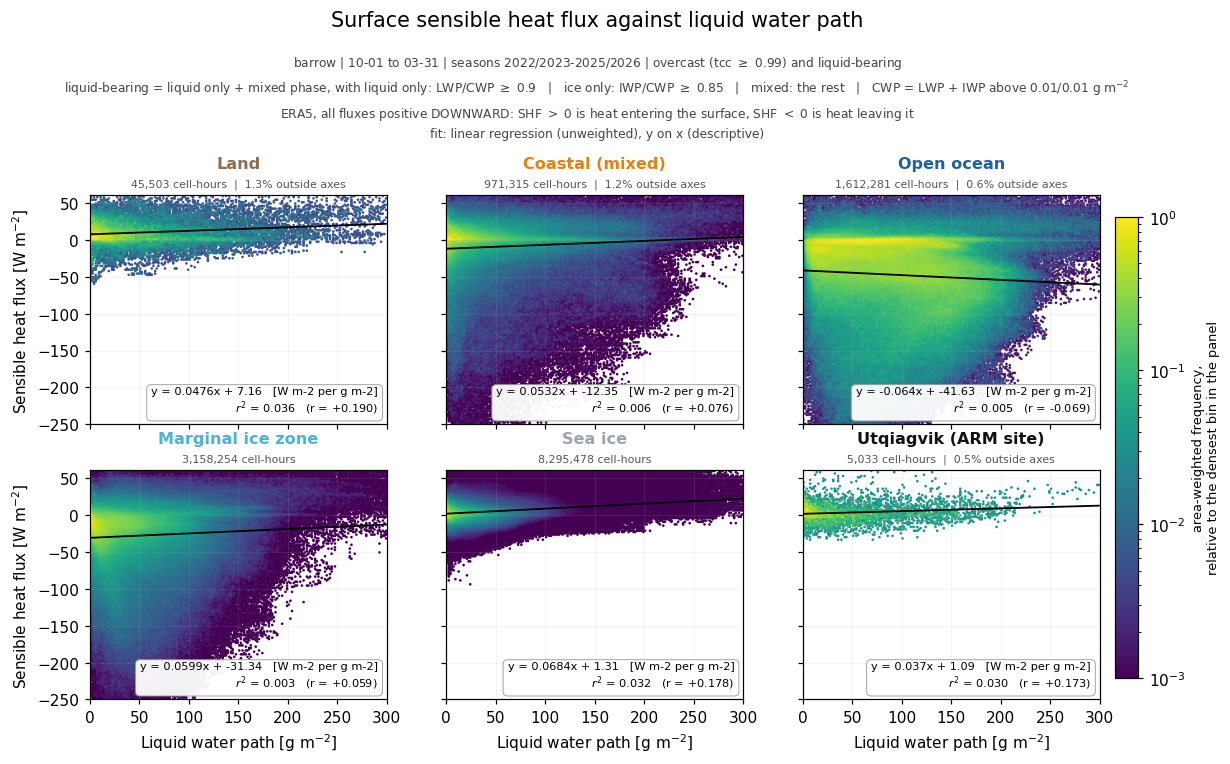

In [5]:
tfr.fig_shf_vs_lwp(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE, fit_orient=FIT_ORIENT);

### 2. Downwelling longwave against sensible heat flux

The same population with the intermediate variable substituted in. DLR is what
the cloud actually delivers to the surface, so this is one step closer to the
mechanism and the relation is correspondingly tighter.

  -> figures/turbulent_response/barrow_shf_vs_dlr_regression_y_on_x_mean2022-2025.png


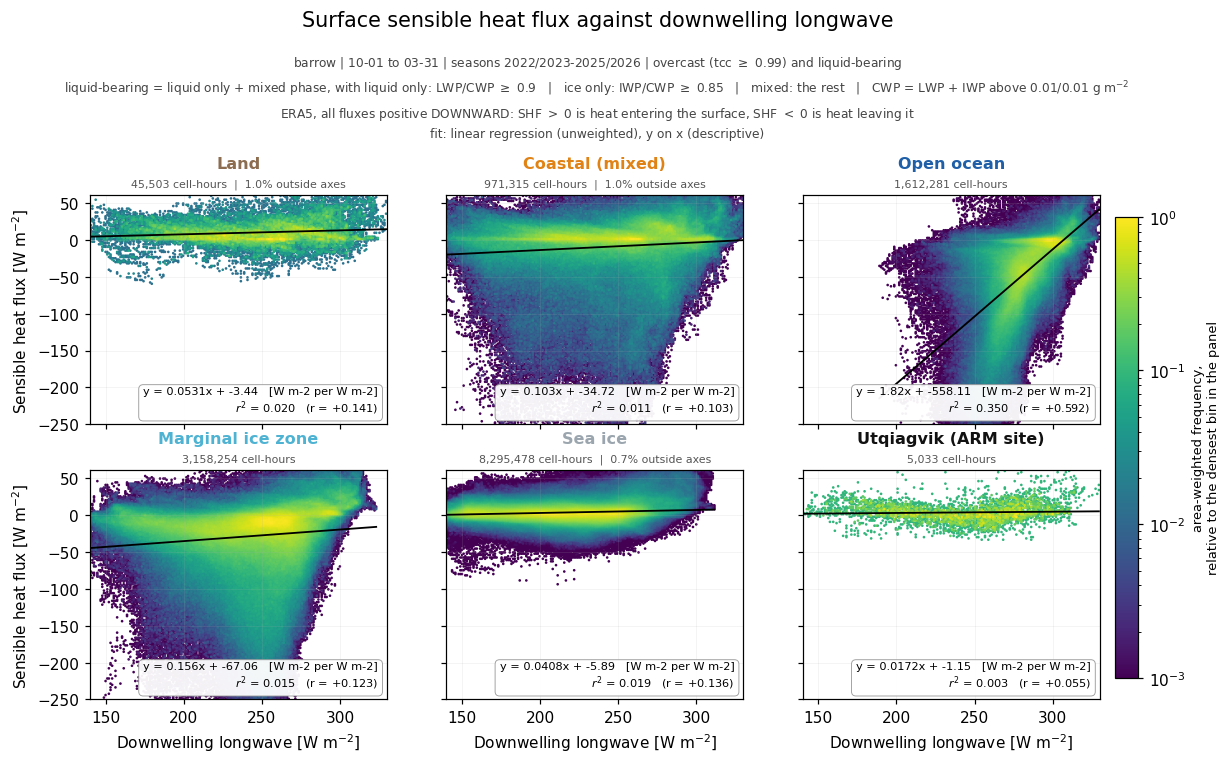

In [6]:
tfr.fig_shf_vs_dlr(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE, fit_orient=FIT_ORIENT);

### 3. The bulk relation itself

Not requested, but it is the premise figures 1 and 2 rest on, and it costs
nothing to draw from the same pass. If ERA5's sensible heat flux is the bulk
flux the argument assumes, this is a line through the origin with slope
$-\rho c_p C_H U$ — and the scatter about it is the wind-speed and stability
dependence that the LWP and DLR panels inherit.

  -> figures/turbulent_response/barrow_shf_vs_dskt_regression_y_on_x_mean2022-2025.png


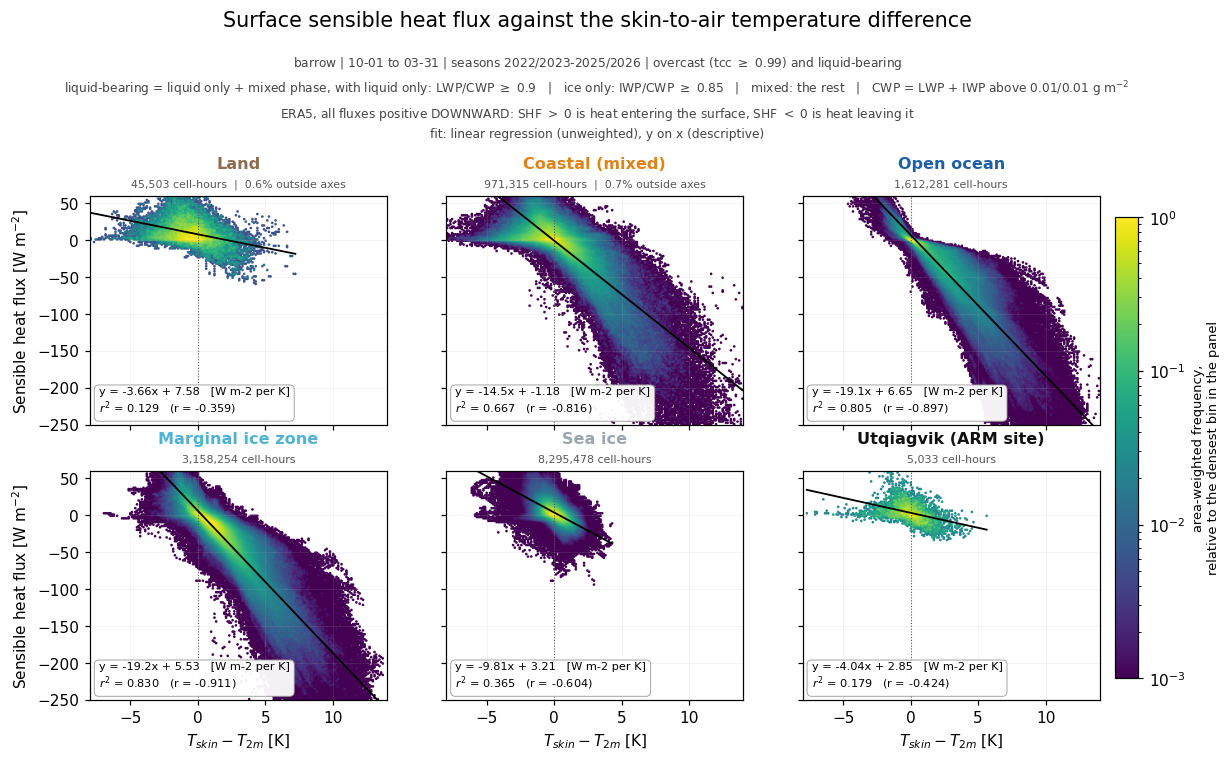

In [7]:
tfr.fig_shf_vs_dskt(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE, fit_orient=FIT_ORIENT);

## The partition, and how it is estimated

With every term positive downward, the surface energy balance is

$$R = LWD - LWU + SW_{net} + SH + LH \qquad [\mathrm{W\,m^{-2}},\ \text{down}]$$

where $R$ is the net convergence, which over ice goes into conduction, storage
and melt. Differentiating with respect to $LWD$ gives an exact partition of each
additional W m⁻² of DLR:

$$1 = f_{LWU} + f_{SH} + f_{LH} + f_{SW} + f_{res}$$

| term | definition | meaning |
|---|---|---|
| $f_{LWU}$ | $\;\;\,d(LWU)/d(LWD)$ | radiated straight back out (Stefan–Boltzmann) |
| $f_{SH}$ | $-d(\mathtt{msshf})/d(LWD)$ | carried away by upward sensible heat flux |
| $f_{LH}$ | $-d(\mathtt{mslhf})/d(LWD)$ | carried away by upward latent heat flux |
| $f_{SW}$ | $-d(SW_{net})/d(LWD)$ | shortwave co-variation ($\approx 0$ in polar night) |
| $f_{res}$ | $\;\;\,d(R)/d(LWD)$ | left over, into the subsurface / melt |

The five sum to one **by construction**, not by luck: the slope operator is
linear and $d(LWD)/d(LWD) = 1$, so $f_{res}$ is defined as the remainder. That
is what makes the stacked bar a genuine budget rather than a collection of
unrelated regressions.

The companion number, $dT_{skin}/d(LWD)$ in K per W m⁻², is the surface's
**thermal freedom** — and $f_{LWU}$ and $f_{SH}$ are both roughly proportional
to it, which is why they rise and fall together across the ice edge.

### Two estimators, and why both are shown

An hour with high DLR is an hour with a cloud, and an Arctic cloudy hour is
usually an hour of warm, moist advection. So $T_{2m}$ rises with DLR — and the
sensible heat flux responds to $T_{2m}$ directly, through the same bulk formula,
with nothing radiative about it.

- **Plain regression** (the default, drawn as bars). Charges the radiation for
  everything the air mass did too, so it is an **upper bound**. Over open water
  it breaks down completely — the surface is pinned near freezing, so
  essentially the whole skin-to-air difference is the *air* moving, and the
  coefficients exceed one. The figures label that case rather than hiding it.
- **Holding $T_{2m}$ fixed** (drawn as markers). Leaves only the pathway running
  through the surface. But $T_{2m}$ is a **mediator** as well as a confounder —
  over sea ice the air temperature is largely slaved to the skin temperature
  beneath it, so the chain DLR → $T_{skin}$ → $T_{2m}$ is a real part of the
  response, and deleting it biases every sensitivity toward zero. A **lower
  bound**.

Neither is the causal answer. Together they bracket it, and the gap between them
is the size of the air-mass confound. Pass `control="t2m"` to either figure to
swap which is the headline.

### 4. The partition by surface class

Panel (a) carries **two** series, and the second is the one that decides the
sign of the turbulent response:

- **solid bars** — $dT_{skin}/d(LWD)$, the surface's thermal freedom. A surface
  that cannot warm cannot radiate more, so this is what $f_{LWU}$ tracks.
- **hatched bars** — $d(T_{skin}-T_{2m})/d(LWD)$. The sensible heat flux follows
  the skin-to-air *difference*, not the skin temperature, so whether a DLR
  increase strengthens or weakens the upward flux depends on which of the two
  temperatures moves further. Where this is negative the air warms faster than
  the surface, the difference shrinks, and the flux moves energy **into** the
  surface — the turbulent term adds to the radiative warming rather than damping
  it.

Panels (c) and (d) are the underlying binned relations, drawn so the slopes in
(a) and (b) can be checked against the curves they came from — a slope taken
across a curve that bends is a summary, not a coefficient.

  -> figures/turbulent_response/barrow_dlr_partition_cloud_none_mean2022-2025.png


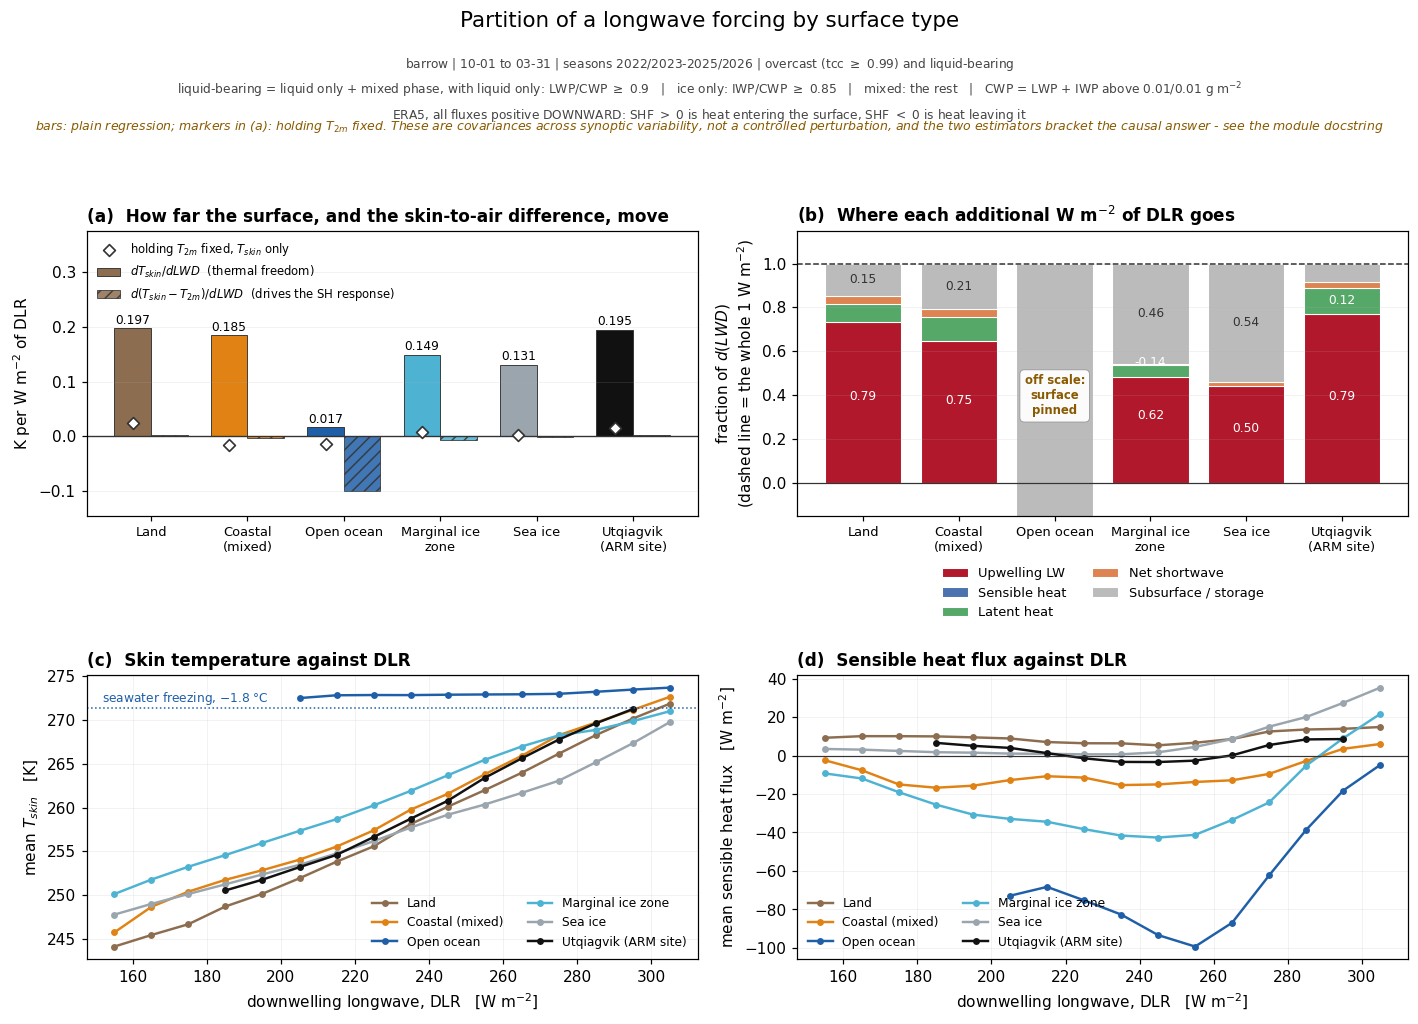

In [8]:
tfr.fig_response_partition(A, out_dir=SAVE_DIR, dpi=DPI);

### 5. The marginal ice zone as a natural experiment

> *Across a short horizontal distance the surface changes from open water near
> −1.8 °C to pack ice tens of degrees colder, while the overlying atmosphere is
> roughly the same air mass. So the marginal ice zone is where the DLR gradient
> and the surface response gradient are both steepest, and comparing them tells
> you how a given change in DLR partitions into skin temperature, upward
> longwave, and turbulent flux — as a function of surface type.*

The three discrete ocean classes cut that continuum into three pieces and then
report a mean for each, which is the wrong shape for the question. Here **sea
ice concentration replaces the class label**, the population is sea cells only,
and the panels read left to right as a transect from open water to pack ice.

- **(a)** sets up the experiment — how much the surface varies across the edge,
  and how much less the forcing does.
- **(b)** is the *surface response gradient*, and it is the direct counterpart
  to the Hovmöller sections of $\partial(DLR)/\partial\mathrm{lat}$ in
  `plot_hovmoller_dlwd_dlat_by_season.ipynb`: that notebook has the **forcing**
  gradient, this panel has the **response** gradient. Three curves —
  $dT_{skin}/d(LWD)$ under both estimators, and
  $d(T_{skin}-T_{2m})/d(LWD)$, which is where the sign of the turbulent
  response is decided.
- **(c)** is the resulting partition, the same five fractions as figure 4 drawn
  as curves. The left end is labelled where the estimator stops meaning what its
  axis says.
- **(d)** is the turbulent flux and its driver, which change sign together
  somewhere inside the band.

  -> figures/turbulent_response/barrow_miz_transect_cloud_none_mean2022-2025.png


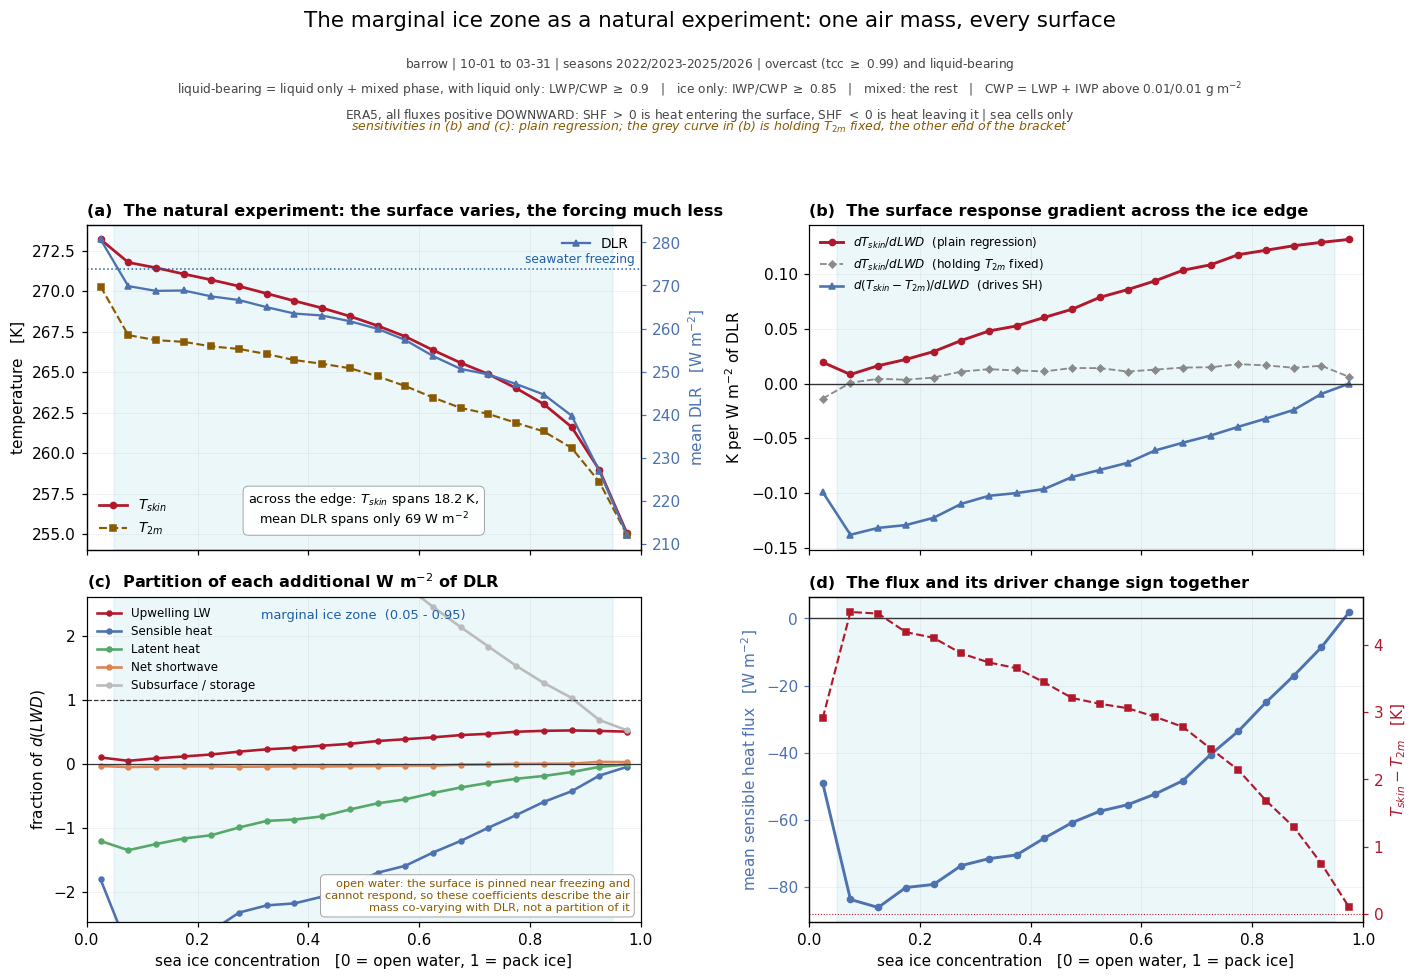

In [9]:
tfr.fig_miz_transect(A, out_dir=SAVE_DIR, dpi=DPI);

### 6. The matched comparison: SHF by cloud regime and surface type

A weak correlation across a heterogeneous population can hide a strong
conditional relationship. Figure 1 pools every surface and every cloud
thickness and returns r² ≈ 0.03 on LWP; that is a statement about the pooled
population, not about the physics inside it.

Stratifying by **LWP regime** and by **surface class** holds the two dominant
confounders roughly fixed within each bar. A difference *between* bars in the
same regime is then a difference between surfaces at comparable cloud forcing;
a difference *across* regimes within one surface is a cloud effect at fixed
surface. That is a matched comparison, and a better estimator of the quantity
in question than a regression slope through the pooled cloud.

**The regime edges are physical, not data-driven.** A liquid cloud's longwave
emissivity is $\varepsilon = 1 - e^{-a\,LWP}$ with $a \approx 0.15$ m² g⁻¹
(Stephens 1978):

| LWP | ε | regime |
|---|---|---|
| 10 g m⁻² | 0.78 | thin — DLR still responds to more liquid |
| 20 g m⁻² | 0.95 | |
| 40 g m⁻² | 0.998 | radiatively black — DLR no longer responds |

so 10 and 40 g m⁻² split the population where the *physics* changes. Terciles
would fall in different places for each class, and comparing classes within a
"regime" would then compare different regimes — reintroducing exactly the
confounding the stratification exists to remove.

**Sample size is encoded twice, deliberately.** Bar *width* is proportional to
log₁₀(cell-hours), which makes a hundredfold disparity visible at a glance, and
the count is *printed* on every bar, which makes it exact. The width encoding is
logarithmic and labelled as such — at a linear encoding the land bars would be
invisible. The whisker is ±1 standard deviation **within** the bin, not a
standard error: with millions of cell-hours the standard error is a fraction of
a W m⁻² and would imply a precision the matching does not have.

  -> figures/turbulent_response/barrow_shf_by_lwp_regime_cloud_mean2022-2025.png


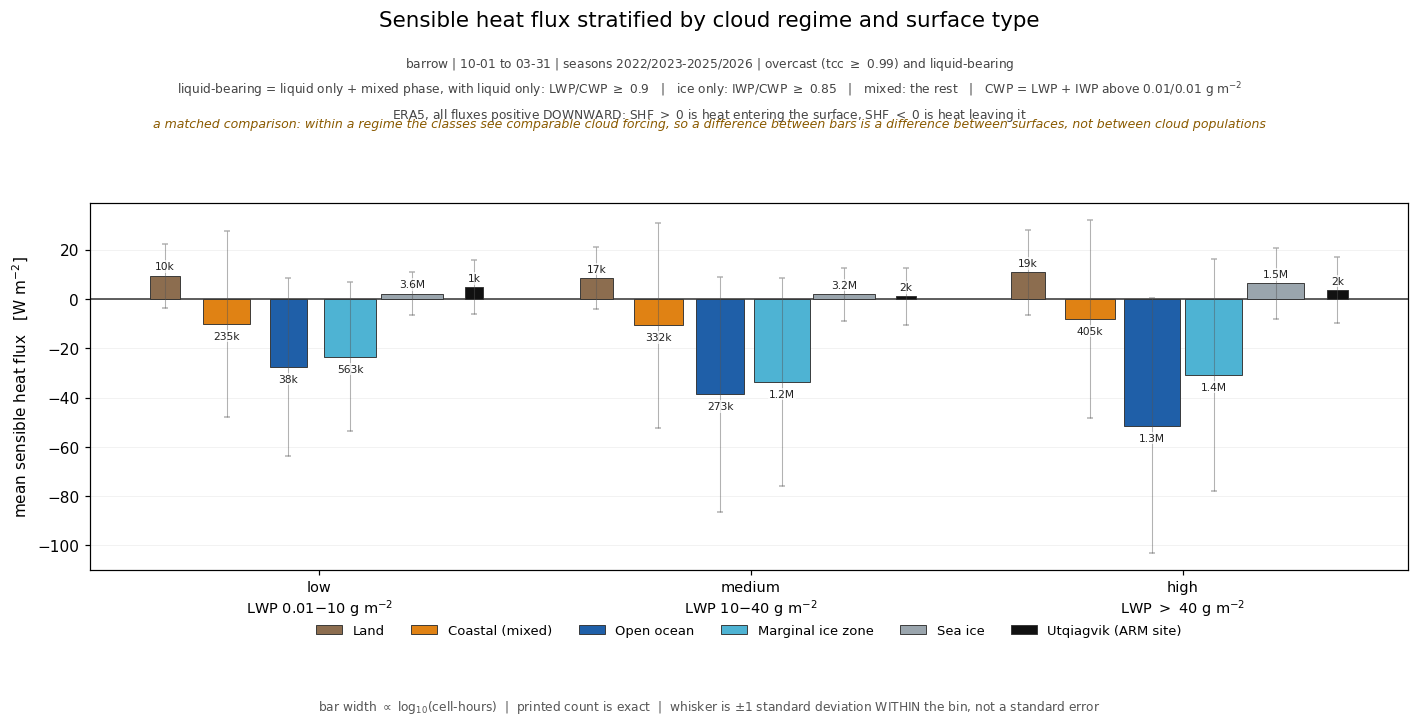

In [10]:
tfr.fig_shf_by_lwp_regime(A, out_dir=SAVE_DIR, dpi=DPI);

### 7. Does the LWP–DLR correlation exist in ERA5?

The ERA5 counterpart to the ARM observational figure from Barrow, on the same
axes (LWP 0–350 g m⁻², DLR 100–350 W m⁻²), coloured the same way (mean cloud
temperature), and fitted in the same direction (DLR on LWP, so the reported
equation is in the same sense as the published `y = 0.27x + 228.26`).

**The colour needs the pressure-level archive.** ERA5's single-level files carry
no cloud temperature, so it is computed as the liquid-weighted mean over the
profile,

$$T_{cloud} = \frac{\sum_l \mathrm{clwc}_l\,\Delta p_l\,T_l}
                    {\sum_l \mathrm{clwc}_l\,\Delta p_l}$$

each level weighted by the liquid water path it contributes. Liquid rather than
total condensate: the x axis is the *liquid* water path, and weighting by total
condensate would let a deep ice layer aloft drag the mean toward a temperature
no liquid ever had.

**That archive is not continuous**, so this figure gets its own `prepare()`.
`data/barrow_pressure` covers Aug–Oct 2022 and then Aug 2024 – Mar 2026, which
gives two complete Oct–Mar seasons: **2024/25 and 2025/26**. Passing
`with_cloud_temperature=True` restricts the whole Analysis to the hours the
pressure archive supplies, so the fit, the density and the colour all describe
the same population — the alternative, colouring only some of the points on a
panel fitted to all of them, is the one thing a comparison figure must not do.

In [11]:
# Its own load: the pressure archive covers only 2024/25 and 2025/26 of the
# Oct-Mar seasons, and with_cloud_temperature restricts the Analysis to match.
A_ct = tfr.prepare(
    region="barrow",
    years=(2024, 2025),
    season_start=(10, 1),
    season_end=(3, 31),
    phase_mode="fraction",
    liquid_fraction_min=0.90,
    ice_fraction_min=0.850,
    min_lwp=0.01,
    min_iwp=0.01,
    min_cloud_fraction=0.99,
    lsm_tol=0.01,
    with_cloud_temperature=True,      # second pass over data/barrow_pressure
    fit_mode=FIT_MODE,
    storage="local",
    dpi=DPI,
)

Turbulent flux response to longwave forcing, by surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 10

  -> figures/turbulent_response/barrow_dlr_vs_lwp_regression_y_on_x_mean2024-2025.png


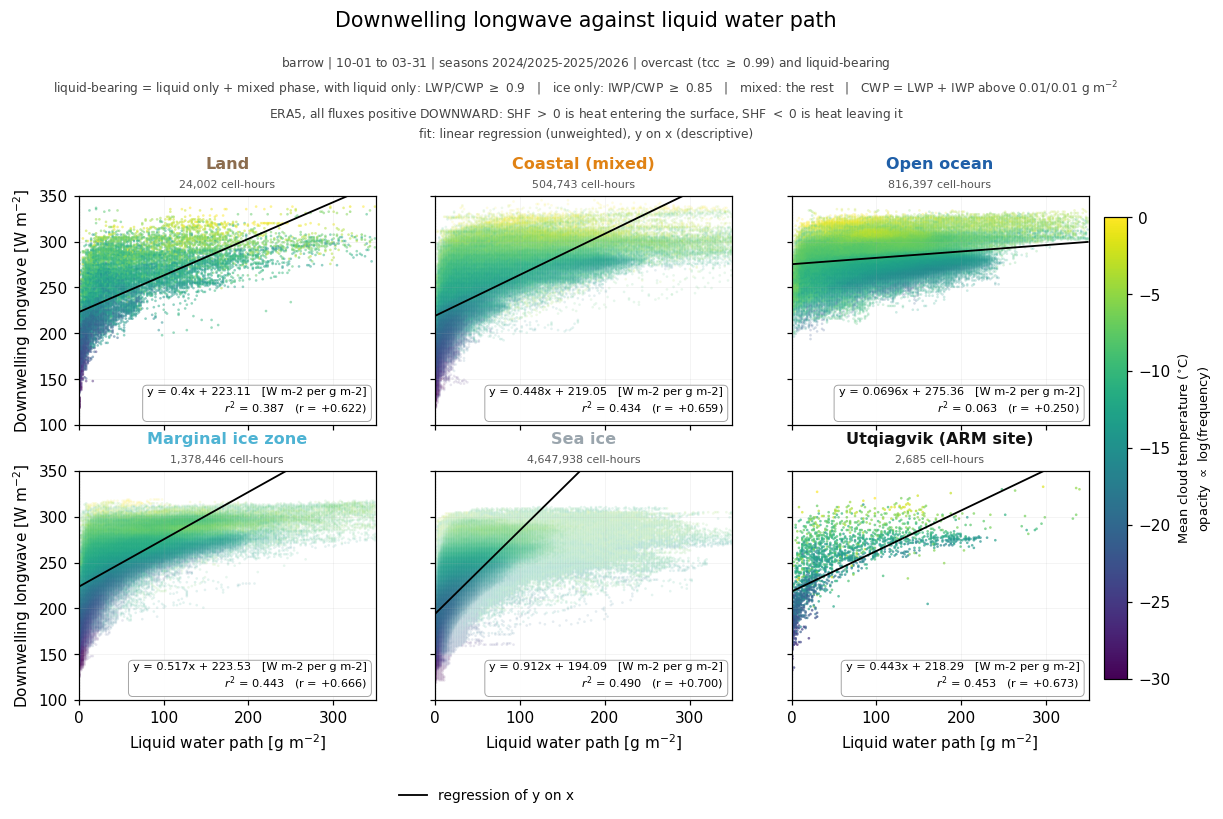

In [12]:
tfr.fig_dlr_vs_lwp(A_ct, out_dir=SAVE_DIR, dpi=DPI);

### 8 and 9. The headline estimate: d(SHF)/d(DLR) and d(LHF)/d(DLR)

Figure 8 is the latent-heat companion to figure 2 — same axes, same fit
direction, so its annotated slope is $d(LHF)/d(DLR)$ directly. Figure 9 puts
both turbulent terms together, per surface type, which is the quantity this
whole notebook is for.

**Both are regressed the right way round.** The flux is the response, so the
flux is on the left:

$$\frac{d(\mathrm{SHF})}{d(\mathrm{DLR})}
 = \frac{\mathrm{cov}(\mathrm{SHF}, \mathrm{DLR})}{\mathrm{var}(\mathrm{DLR})}$$

and likewise for LHF. `self_check()` verifies this agrees across all four code
paths that compute it — the partial regression, `moment_stats` with swapped
arguments, the `x_on_y` member of `fit_pair`, and the negated partition
fraction $-f_{SH}$ — to 1e-9.

**Sign, once more.** ERA5 is positive downward, so a *positive*
$d(\mathrm{SHF})/d(\mathrm{DLR})$ means more DLR goes with more heat flowing
**into** the surface: the turbulent term *adds* to the radiative warming.
Negative is the damping the bulk argument expects.

**Why the latent term belongs here.** It is the other half of the turbulent
flux and it is not small — over most classes $|d(LHF)/d(DLR)|$ is comparable to
or larger than the sensible term, and the two do not always share a sign. A
turbulent-flux budget that stops at sensible heat is incomplete.

  -> figures/turbulent_response/barrow_lhf_vs_dlr_regression_y_on_x_mean2022-2025.png


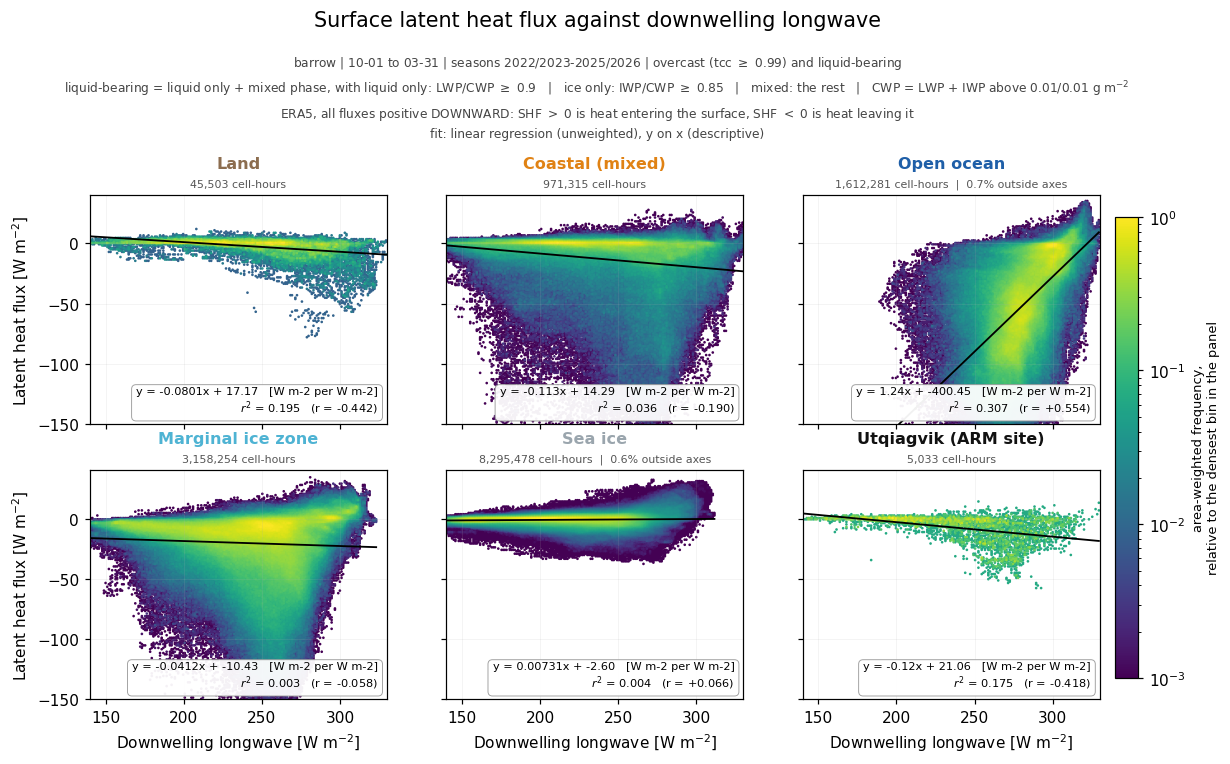

In [13]:
tfr.fig_lhf_vs_dlr(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

  -> figures/turbulent_response/barrow_turbulent_response_cloud_none_mean2022-2025.png


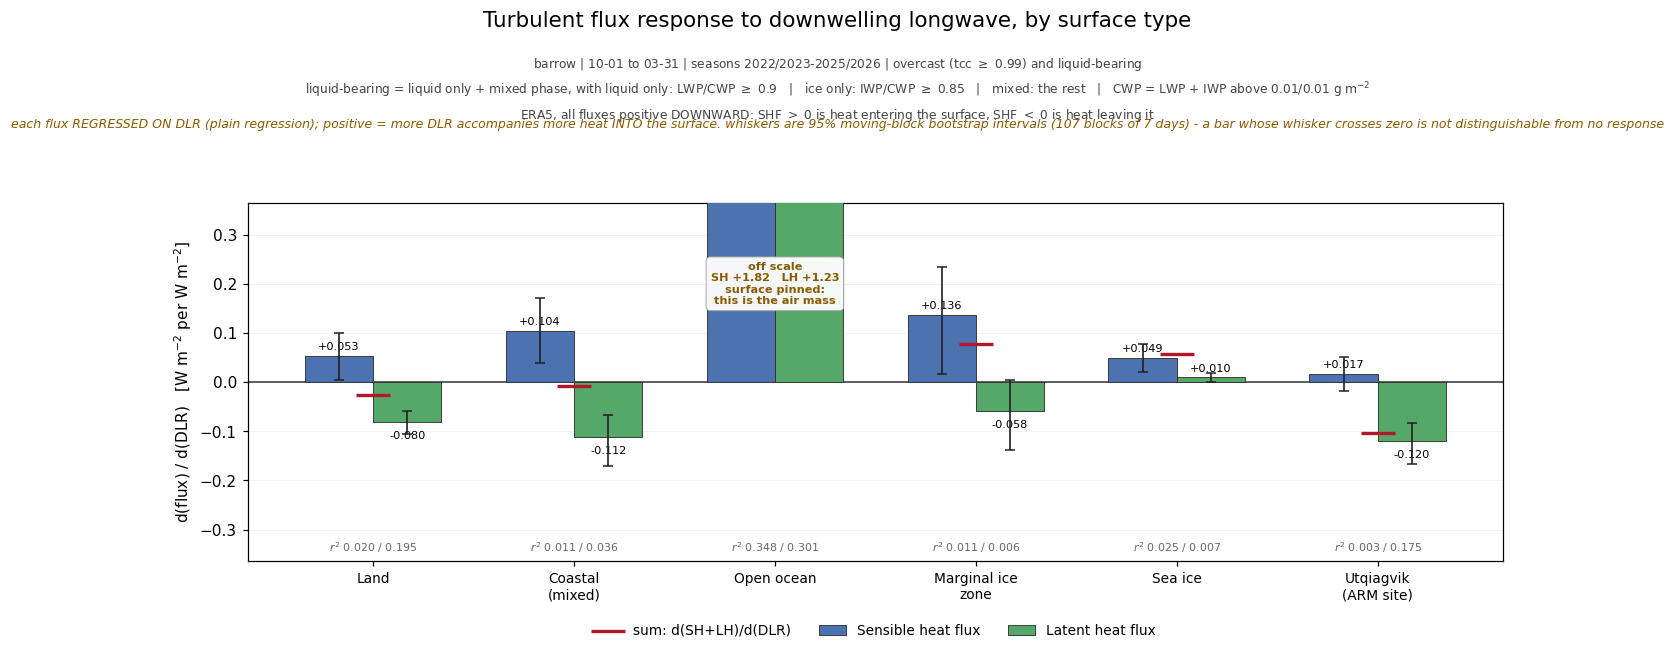

In [14]:
tfr.fig_turbulent_response(A, out_dir=SAVE_DIR, dpi=DPI);

## Weighting: should this be weighted least squares?

Short answer: **the cos(latitude) weights are not the kind of weighting the
regression literature means, and neither weighting scheme is wrong — they
answer different questions.** Both are computed in the same pass and printed
side by side, so the choice is settled by inspection rather than argument.

### Two completely different things called "weighting"

| | statistical weighting | area weighting |
|---|---|---|
| weight | $1/\sigma_i^2$ | $\cos(\text{lat}_i)$ |
| purpose | efficiency and freedom from bias when measurement errors differ between points | making the estimate represent a **region** rather than a set of cells |
| fails if omitted | slope is inefficient, and biased if $x$ has error | the answer over-represents high latitudes |

Wu & Yu (2018), *Evaluation of linear regression techniques for atmospheric
applications: the importance of appropriate weighting*, **AMT** 11, 1233–1250,
[doi:10.5194/amt-11-1233-2018](https://doi.org/10.5194/amt-11-1233-2018), is
about the **first** column. Their finding — OLS gives biased slope *and*
intercept when both $x$ and $y$ carry measurement error, and the bias grows as
$r^2$ falls below ~0.9 — is a statement about errors-in-variables, and their
remedy is Deming, weighted orthogonal distance, or York regression with weights
$\omega = 1/\sigma^2$.

### Does their warning apply here? Mostly no, and it matters why

**Within ERA5, $x$ has no measurement error.** DLR is not measured with
uncertainty; it is the model's own value, read exactly from the file. For the
question *"what is the relationship inside ERA5?"* the OLS assumption of an
error-free predictor is exactly satisfied, and OLS is the right estimator.

If instead the question were *"what is the relationship in nature, estimated
via ERA5?"*, both variables would carry model error and an errors-in-variables
method would be appropriate in principle. But it is not usable here: those
errors come from the *same* model physics and are therefore strongly
correlated, which violates what Deming and York assume, and nobody has an
hourly grid-cell $\sigma$ for ERA5 DLR or SHF to weight with. Wu & Yu are
explicit that a wrong $\lambda = \omega(X)/\omega(Y)$ biases both slope and
intercept — an assumed $\lambda$ would be worse than none.

**The low $r^2$ here is not measurement error.** Wu & Yu's $r^2 < 0.9$
threshold is about error magnitude relative to signal. Our $r^2$ of 0.01–0.35
comes from *omitted variables* — wind, stability, air mass — not from noisy
instruments. Errors-in-variables regression is the wrong remedy for that; the
right ones are multiple regression and stratification, which is what the next
section and figure 6 do. Applying an EIV method to omitted-variable scatter
would inflate the slope while fixing nothing.

One thing of theirs that does transfer: **the slope is more robust than the
intercept.** Treat every intercept in this notebook as decoration.

### The case FOR weighting by cos(latitude)

- The estimand may be a property of a **region**. A grid cell at 70 °N covers
  twice the ground of one at 80 °N, so counting cells equally over-represents
  the north of the strip by about 2:1.
- The surface classes are **not distributed uniformly in latitude** — sea ice
  sits north, open water south — so unweighted pooling silently shifts the
  class mix as well as the geography.
- It is what the rest of the surface-energy-budget literature does, and what
  the other scripts in this directory do.

### The case AGAINST — why the headline numbers are unweighted

- **The estimand here is per-column, not per-unit-area.** "Given a grid cell of
  this class under this cloud, how does its flux respond to DLR?" is a question
  about an atmospheric column. Each column answers once.
- **The comparison with ARM is per-column.** A radiometer at Utqiagvik samples
  one column; area-weighting would have ERA5 answer a different question than
  the observation does.
- **These weights do not improve efficiency.** $\cos(\text{lat})$ is not
  $1/\sigma^2$, so Gauss–Markov does not apply — a weighted fit with
  non-variance weights is *less* efficient than OLS when the errors are
  homoscedastic. It buys representativeness, not precision.
- **The residual heteroscedasticity that is real does not need fixing either.**
  Scatter genuinely is larger over open water and at high DLR, but OLS stays
  unbiased under heteroscedasticity — only the standard error is wrong, and
  ours comes from a block bootstrap, which is heteroscedasticity-robust
  already.
- **Measured, it does not matter.** Across 70–80 °N, $\cos(\text{lat})$ varies
  by only a factor of two. The report prints both, and they agree to 1–15% on
  slope and to three decimals on $r^2$.

### Recommendation

Keep **unweighted OLS as the headline** for the per-column questions, which is
all of the flux-response work. Use the **area-weighted** column whenever
quoting a regional mean — a domain-average sensitivity, or anything compared
against a gridded product. Report both, which the module does by default, and
say which one a quoted number came from. Where the two disagree by more than a
few percent — sea ice on figure 1, 0.389 vs 0.333 — that disagreement is itself
telling you the relation varies with latitude inside that class, which is worth
a sentence rather than a choice of estimator.

---

## Confounders: what may be controlled for, and what must not be

Adding a control variable is not a free improvement. The wrong one biases the
answer as surely as omitting the right one, and which is which follows from the
causal structure, not from whether the fit improves.

The bulk formulae name the structure:

$$\mathrm{SH}_{up} \approx \rho c_p C_H U\,(T_{skin}-T_{2m}),
\qquad
\mathrm{LH}_{up} \approx \rho L_v C_E U\,(q_{sat}(T_{skin})-q_{2m})$$

and the pathway under test is

$$\mathrm{DLR} \longrightarrow T_{skin} \longrightarrow (T_{skin}-T_{2m})
\longrightarrow \mathrm{SHF}$$

**The rule.** Control for a variable that influences $y$ through a path that
does **not** run through $x$, and that is correlated with $x$. Three kinds must
be left alone:

| kind | example here | what goes wrong |
|---|---|---|
| **Mediator** — on the path $x \to \cdots \to y$ | $T_{skin}$, $(T_{skin}-T_{2m})$ | removes the very effect being estimated; hold the skin temperature fixed and DLR can do nothing by construction |
| **Collider** — caused by both $x$ and $y$ | — | manufactures an association that is not there |
| **Cause of $x$ alone** | **LWP, cloud opacity** | harmless but useless: strips the variance in $x$ the regression is using, and removes no bias |

**This answers the cloud question directly.** Liquid water path and cloud
opacity are *causes of DLR*. In polar night they reach the turbulent fluxes
only *through* DLR — there is no shortwave path — so they are causes of the
predictor with no separate route to the response. **Do not control for them.**
More generally: you never need to explain why $x$ varies in order to estimate
$dy/dx$. That is what a regression on $x$ already does.

**What is left, and why each qualifies:**

- **Wind speed** — multiplies the exchange coefficient, so it drives both
  fluxes directly, and Arctic storms are both cloudy and windy. Not on the
  DLR → $T_{skin}$ → flux path. A clean confounder and the least controversial
  control here.
- **2 m air temperature** — enters SHF directly through the skin-to-air
  difference, and warm advection raises it *and* DLR. But it is also a
  **mediator**, because DLR warms the skin which warms the air. Its rung is a
  lower bound, not a better estimate.
- **2 m humidity**, for the latent flux — enters LHF directly through the
  humidity difference, and water vapour is itself a strong longwave emitter, so
  it raises DLR too. The confounding is *stronger* than the temperature case,
  because the path from humidity to DLR is direct radiative physics rather than
  advection. Same mediator caveat.
- **Surface pressure**, as a circulation proxy — Bertrand et al. test whether
  synoptic variability explains their trend by stratifying on daily surface
  pressure anomaly; carrying it as a regression control is the same check in
  another form.

### A specification point that matters more than any of the controls

The bulk formulae are **multiplicative** in wind speed: a 5 K skin-to-air
difference moves twice the heat at 10 m s⁻¹ that it does at 5. Adding wind as
an extra *additive* term only approximates that. Regressing on the product
$U\Delta T$ — the predictor the physics actually names — is the correctly
specified fit, and its slope is $\rho c_p C_H$ with no wind speed left in the
units. The improvement is large:

| class | SHF ~ $\Delta T$ | SHF ~ $U\Delta T$ | LHF ~ $\Delta q$ | LHF ~ $U\Delta q$ |
|---|---|---|---|---|
| Land | 0.129 | **0.273** | 0.261 | **0.453** |
| Coastal | 0.664 | **0.883** | 0.697 | **0.907** |
| Open ocean | 0.800 | **0.983** | 0.609 | **0.973** |
| Marginal ice zone | 0.826 | **0.937** | 0.756 | **0.928** |
| Sea ice | 0.371 | **0.466** | 0.524 | **0.664** |
| Utqiagvik | 0.179 | **0.338** | 0.466 | **0.748** |
| *All cells* | *0.810* | ***0.935*** | *0.803* | ***0.953*** |

($r^2$; four seasons.) Over open water $r^2$ goes from 0.80 to **0.98**, and
pooled over the domain from 0.81 to **0.94**. Most of what looked like unexplained scatter in figure 3 was never
missing physics — it was wind speed. ERA5's turbulent fluxes really are the
bulk formulae, and once the predictor is written correctly they are nearly
deterministic. That is also the strongest argument for keeping wind in the
control set everywhere else.

### 10. Does controlling for a confounder move the answer?

Four regressions, each under a ladder of control sets, with block-bootstrap
intervals. This turns "what should I control for" from an argument into a
measurement: **a slope that barely moves as a control is added is evidence that
the confounder was not doing much** — which is a result, and the same logic
Bertrand et al. use to conclude that circulation variability cannot explain
their trend.

| panel | regression | ladder |
|---|---|---|
| (a) | SHF on LWP | none → wind → wind, $T_{2m}$ |
| (b) | SHF on DLR | none → wind → wind, $T_{2m}$ → wind, $T_{2m}$, $p_s$ |
| (c) | SHF on $\Delta T$ (the coupling coefficient) | none → wind → wind, $p_s$ |
| (d) | LHF on DLR | none → wind → wind, $q_{2m}$ → wind, $q_{2m}$, $T_{2m}$ |

Remember which rungs are honest confounders and which are mediators: wind and
surface pressure are confounders, so their rungs *improve* the estimate;
$T_{2m}$ and $q_{2m}$ are mediators as well, so their rungs *bound* it from
below.

  -> figures/turbulent_response/barrow_control_ladder_cloud_mean2022-2025.png


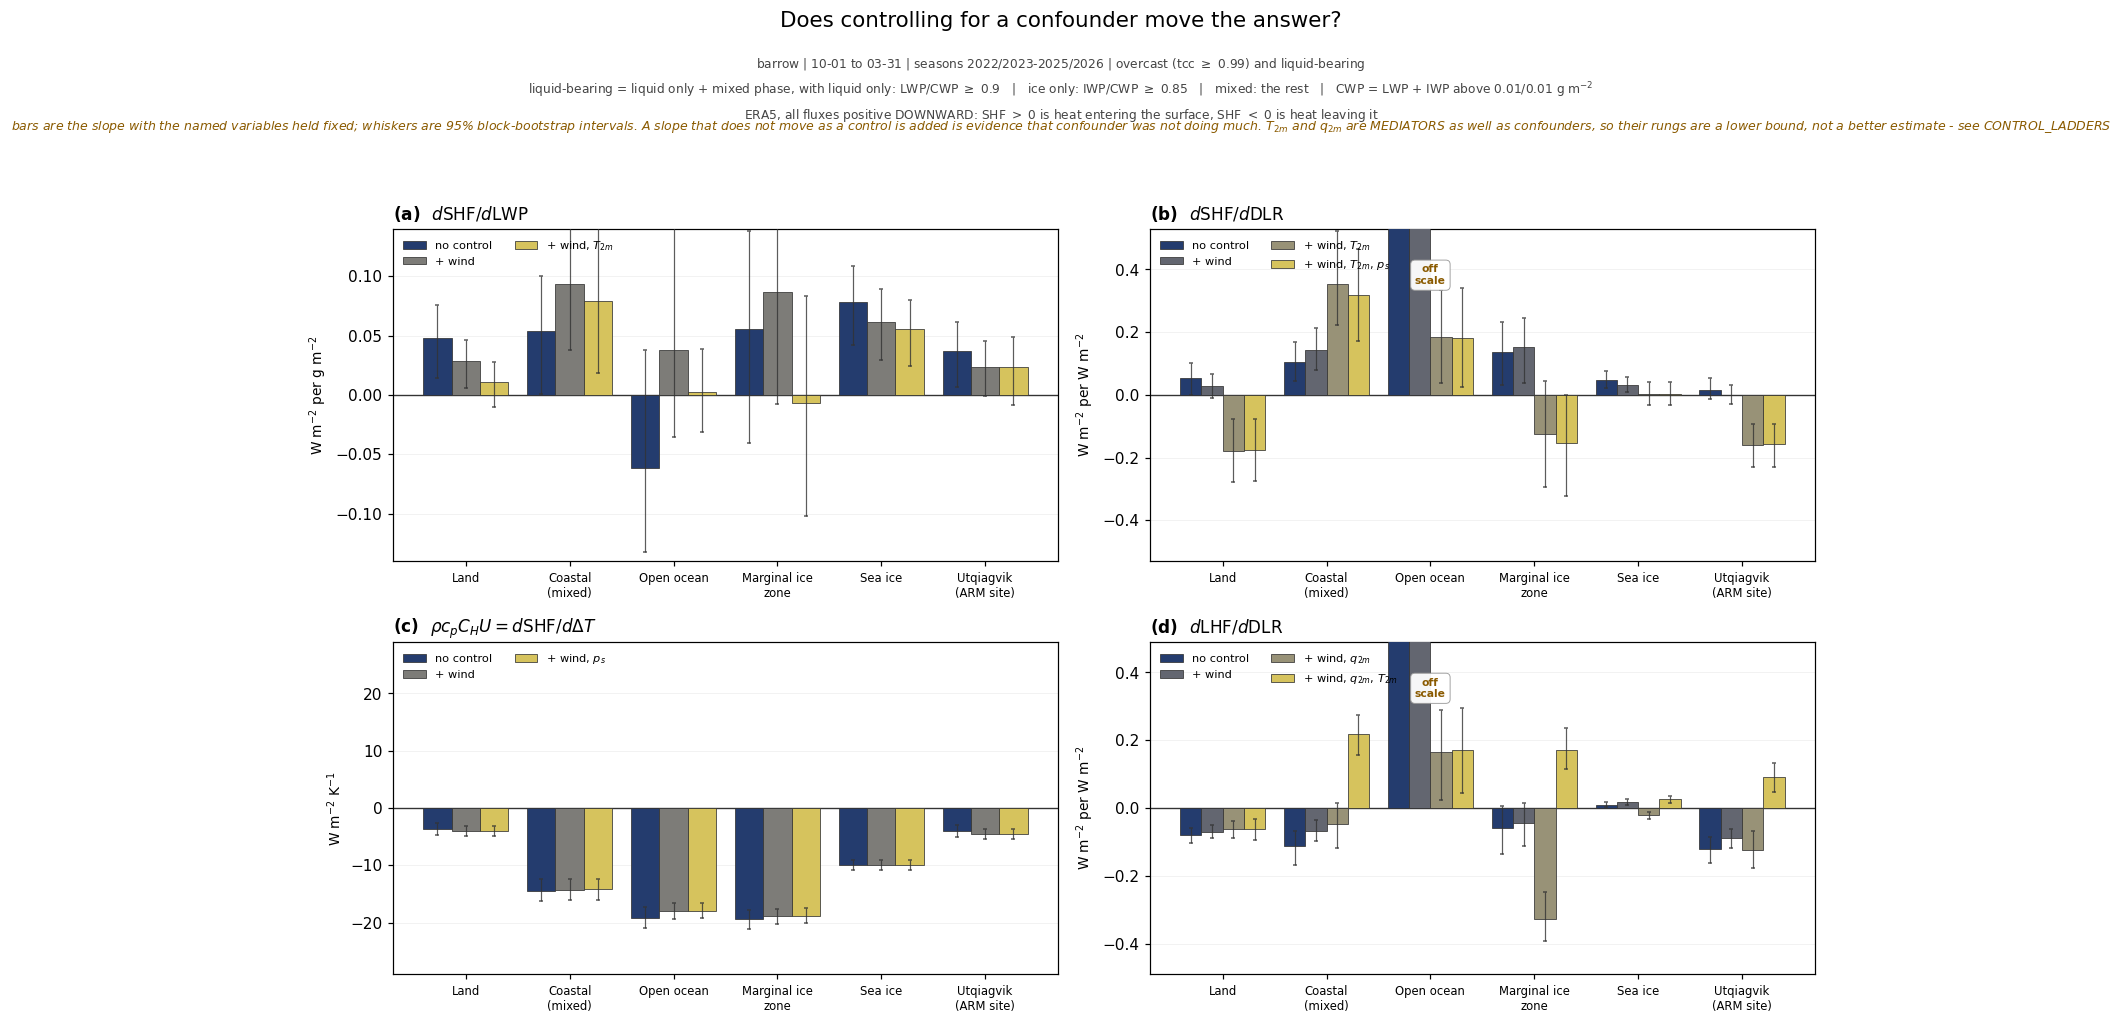

In [15]:
tfr.fig_control_ladder(A, out_dir=SAVE_DIR, dpi=DPI);

## What this record actually shows

Barrow strip, Oct–Mar, seasons 2022/23–2025/26, overcast and liquid-bearing
under the **fractional** phase scheme above: 14.08 million cell-hours. Plain
regression unless noted.

**The headline number, both turbulent terms, regressed on DLR.** Four seasons,
14.08 million cell-hours, plain regression, ERA5 positive downward. Intervals
are 95% moving-block bootstrap (107 blocks of 7 days, 2,000 replicates):

| class | $d\mathrm{SHF}/d\mathrm{DLR}$ | 95% CI | $d\mathrm{LHF}/d\mathrm{DLR}$ | 95% CI | sum |
|---|---|---|---|---|---|
| Land | +0.053 | [+0.004, +0.101] | −0.080 | [−0.105, −0.058] | **−0.027** |
| Coastal | +0.104 | [+0.039, +0.171] | −0.112 | [−0.170, −0.066] | **−0.008** |
| Marginal ice zone | +0.136 | [+0.017, +0.235] | −0.058 | [−0.137, +0.005] | **+0.078** |
| Sea ice | +0.049 | [+0.020, +0.078] | +0.010 | [+0.001, +0.019] | **+0.058** |
| Utqiagvik cell | +0.017 | [−0.018, +0.052] | −0.120 | [−0.166, −0.083] | **−0.103** |
| *Open ocean* | *+1.817* | *[+1.348, +2.247]* | *+1.232* | *[+0.912, +1.492]* | *+3.049* |

The naive OLS standard errors for these slopes are 14× to 172× too small — for
sea ice, 0.00010 against a bootstrap 0.0149. Read against the naive intervals
every one of these would look nailed down to three or four figures.

Three things follow.Three things follow.

**(i) The sensible term has the opposite sign from the naive expectation, and
it is small.** Over every land and ice class $d\mathrm{SHF}/d\mathrm{DLR}$ is
*positive*: more DLR goes with more heat flowing **into** the surface, so the
turbulent term adds to the radiative warming rather than damping it. The reason
is in point 2 below — the air warms as fast as the surface does, so the
skin-to-air difference barely moves. The magnitude, 0.05–0.14 W m⁻² per W m⁻²,
is an order of magnitude below the radiative damping $f_{LWU} = 0.50$–0.79.

**(ii) The latent term is the same size and usually the opposite sign, so they
cancel.** Adding it changes the picture: the *total* turbulent response is
−0.03 to +0.08 over land and ice — under a tenth of a watt per watt, and of
inconsistent sign. Any account of the turbulent response that stops at sensible
heat is reporting half of a near-cancellation.

**(iii) Open water is not a surface response at all.** 1.82 and 1.23 sum to
3.05 W m⁻² per W m⁻² — more energy moving than the radiation delivered, which
is impossible as a partition. The surface is pinned near freezing while the air
is free, so the regression is tracking the air mass. The figures label this
rather than hiding it.

**Where the intervals come from, in one paragraph.** ERA5 is not a set of
independent draws of nature — reading the file twice gives the same number — so
the textbook standard error, which divides by $\sqrt{n}$ with $n$ =
cell-hours, is meaningless here. What *is* uncertain is whether a slope is a
property of the climate or an accident of the particular weather that happened.
The record contains repeated draws of *that*: roughly 60 independent synoptic
situations per season, because DLR has a lag-1 hourly autocorrelation of 0.988
(one independent sample per ~3 days) and stays correlated across the whole
domain. So the interval is built by **chopping the record into 7-day blocks,
drawing blocks at random with replacement to assemble 2,000 synthetic records,
and refitting on each**. The spread of slopes across those synthetic records is
the sampling distribution. Blocks rather than individual points, because a
block keeps a weather system intact; whole spatial fields inside each block, so
the spatial correlation is carried along and never has to be estimated. Longer
section: "How can ERA5 have a confidence interval at all?" above.

**On significance.** With four seasons the sensible-heat responses over the
area classes do clear zero, but only just, and they remain small. The single
Utqiagvik grid cell does **not** — [−0.018, +0.052] — which is the honest
statement for 5,033 cell-hours from one cell, and a useful warning against
reading the site panel of the scatter figures as if it carried the same weight
as the class panels. On one season rather than four, sea ice does not clear
zero either.

The r² values are also worth keeping in view: except over open water these
slopes are drawn through a great deal of scatter (r² = 0.003–0.035). A slope
can be well determined and still explain almost none of the variance — the two
are different questions, and it is the reason figure 6 stratifies rather than
leaning harder on the regression.

**0. What changing the phase scheme did.** Moving from the absolute g m⁻²
thresholds to the fractional scheme costs 8.2% of the sample overall, and the
loss is strongly class-dependent — it falls hardest where clouds are
ice-dominated:

| class | absolute | fractional | change |
|---|---|---|---|
| Land | 58,398 | 45,503 | −22.1% |
| Coastal | 1,174,261 | 971,315 | −17.3% |
| Open ocean | 1,860,811 | 1,612,281 | −13.4% |
| Marginal ice zone | 3,503,188 | 3,158,254 | −9.8% |
| Sea ice | 8,750,537 | 8,295,478 | −5.2% |
| **All** | **15,347,195** | **14,082,831** | **−8.2%** |

The scheme change moves every number by a few percent and moves **none of the
conclusions**, which is the useful result: what follows is a property of the
atmosphere, not of where the phase threshold was put.

**1. The bulk relation holds, and the coupling is *not* uniform across
surfaces.** Regressing SHF on $\Delta T$ — not the reverse, see above — gives
$\rho c_p C_H U = -d(SHF)/d(T_{skin}-T_{2m})$:

| class | W m⁻² K⁻¹ | r² | (inverting the wrong fit would give) |
|---|---|---|---|
| Marginal ice zone | 19.4 | 0.83 | 23.4 |
| Open ocean | 19.1 | 0.80 | 23.9 |
| Coastal | 14.4 | 0.66 | 21.7 |
| **Sea ice** | **9.9** | 0.37 | 26.7 |
| Utqiagvik | 4.0 | 0.18 | 22.5 |
| Land | 3.7 | 0.13 | 28.3 |

Pack ice couples to the atmosphere about **half as strongly** as open water or
the ice edge — a stable boundary layer over a smooth, cold surface, exactly as
expected, and a real difference between surface types that the inverted
estimates (last column, uniform at 22–28) completely hide. The land and site
values sit on r² ≈ 0.15 and should be read as *unmeasured*, not as small.

ERA5's sensible heat flux is the bulk flux the argument assumes, so the
mechanism is available in principle; the question is whether its driver moves.

**2. But the skin-to-air difference barely responds to DLR over land or ice.**
$T_{skin}$ and $T_{2m}$ move together almost one-for-one:

| class | $dT_{skin}/dLWD$ | $dT_{2m}/dLWD$ | $d(T_{skin}-T_{2m})/dLWD$ |
|---|---|---|---|
| Land | 0.198 | 0.195 | +0.003 |
| Marginal ice zone | 0.149 | 0.157 | −0.007 |
| Sea ice | 0.131 | 0.131 | −0.000 |
| Open ocean | 0.017 | 0.117 | **−0.100** |

(K per W m⁻²). Over ice and land the air warms right along with the surface, so
the driver of the turbulent flux is nearly invariant to DLR and the turbulent
term is **small**: $|f_{SH}| \leq 0.14$, against a radiative damping
$f_{LWU} = 0.50$–$0.79$. On this record the surface returns a DLR anomaly
mostly through **upwelling longwave**, not through turbulence.

Note that $f_{SH}$ is *negative* for every class — the air warms marginally
faster than the surface, so more DLR nudges the flux toward carrying heat
**into** the surface. Small, but it is the opposite sign from the naive
expectation, and it is worth knowing that the naive expectation fails here for
a reason (air–surface coupling) rather than by accident.

**2b. How much of $f_{SH}$ is the bulk pathway at all?** With the coupling now
estimated in the right direction the two can be multiplied: the part of
$f_{SH}$ running through the skin-to-air difference is
$\rho c_p C_H U \times d(\Delta T)/d(LWD)$, and the remainder is wind and
stability co-varying with cloud cover.

| class | coupling × $d\Delta T/dLWD$ | actual $f_{SH}$ | share |
|---|---|---|---|
| Open ocean | −1.91 | −1.82 | ~all |
| Marginal ice zone | −0.138 | −0.136 | ~all |
| Coastal | −0.032 | −0.104 | 30% |
| **Sea ice** | **−0.004** | **−0.049** | **8%** |
| Land | +0.010 | −0.053 | wrong sign |

Over open water and the ice edge the bulk temperature pathway *is* the whole
turbulent response. Over pack ice it accounts for under a tenth of an already
small $f_{SH}$: what little turbulent response there is comes from wind and
stability travelling with the cloud, not from the mechanism this notebook set
out to test. With the inverted coupling (26.7) that share would have read 22%,
nearly 3× too high — the direction of the fit changes the interpretation, not
just the number.

**3. The one place the turbulent term matters is open water — and there it has
the opposite sign, strongly.** The surface is pinned near freezing while the
air is free, so $d(T_{skin}-T_{2m})/dLWD = -0.100$ K per W m⁻²: more DLR
shrinks the skin-to-air difference sharply and the flux swings toward carrying
heat *into* the surface. That is why $f_{SH}$ for open ocean is not just
negative but far larger than one — the regression there is describing the air
mass, not a partition of the radiation, which is what the "off scale" label on
figure 4(b) and the caveat box on figure 5(c) mark.

**4. Stratifying rescues the signal the pooled regression destroyed.** Mean SHF
by LWP regime and surface class, four seasons (figure 6):

| class | low | medium | high | high − low |
|---|---|---|---|---|
| Land | +9.3 | +8.5 | +10.7 | +1.4 |
| Coastal | −10.1 | −10.7 | −8.0 | +2.1 |
| **Open ocean** | −27.5 | −38.8 | −51.5 | **−24.0** |
| Marginal ice zone | −23.4 | −33.7 | −30.8 | −7.4 |
| **Sea ice** | +2.2 | +1.9 | +6.2 | **+4.1** |
| *All cells pooled* | *−2.7* | *−10.9* | *−23.8* | *−21.2* |

(W m⁻².) Two things to read off this. First, the conditional effect **exists
and is large where the surface can respond**: over open water, thickening the
cloud from thin to LW-black drives the turbulent flux 24 W m⁻² further
negative. The pooled r² ≈ 0.03 on figure 1 was not telling you the effect was
absent — it was telling you the pooled population is heterogeneous.

Second, and more important: **the pooled row is mostly composition, not
physics.** The pooled swing of −21.2 W m⁻² looks like the open-ocean number,
but the high-LWP bin is 28% open ocean by cell-hours while the low-LWP bin is
0.9%. The pooled trend is largely a change in which surfaces are present.
Within sea ice — 8.3 of the 14.1 million cell-hours — the effect is **+4.1**,
the opposite sign from the pooled trend. Any statement about "the" turbulent
response to cloud thickening that does not name a surface type is averaging
over a sign change.

**5. The LWP–DLR correlation exists in ERA5, and is tighter than observed.**
The Utqiagvik cell, seasons 2024/25–2025/26, against the ARM figure from
Barrow:

| | slope | intercept | r² | N |
|---|---|---|---|---|
| **ERA5**, Utqiagvik cell | 0.443 | 218.3 | 0.453 | 2,685 h |
| **ARM**, Barrow | 0.270 | 228.3 | 0.260 | 1,663 h |

The correlation is confirmed and the intercepts agree to 10 W m⁻² — reassuring,
since the intercept is the clear-sky-plus-thin-cloud limit. But ERA5's slope is
64% steeper and its r² is 1.7× higher: the reanalysis binds LWP and DLR more
tightly than the observations do. That is the expected direction — ERA5's LWP
and DLR come from the same model radiation scheme and are dynamically
consistent by construction, whereas the ARM pair are independent instruments
carrying independent retrieval error, which attenuates r² and the slope. Treat
the gap as a hypothesis to test, not as a measured bias.

Across classes the ERA5 slope runs 0.070 (open ocean) to 0.912 (sea ice): the
colder and drier the background, the more each gram of liquid adds. Open ocean
is the outlier because DLR there is already set by a warm, moist boundary layer
and the cloud adds little.

**So the proposed damping is real in the bulk formula but weak in the
covariance**, because ERA5's near-surface air is tightly coupled to the surface
it sits over. The exception is the ice edge, and it runs the other way. Treat
all of this as covariance, not causation — the two estimators bracket it, and
over ice they bracket it widely.

## Redraw everything

Same set the command-line run writes. The scatter filenames carry the fit mode,
so `"default"` and `"regression"` copies coexist rather than overwriting each
other.

  -> figures/turbulent_response/barrow_shf_vs_lwp_regression_y_on_x_mean2022-2025.png
  -> figures/turbulent_response/barrow_shf_vs_dlr_regression_y_on_x_mean2022-2025.png
  -> figures/turbulent_response/barrow_shf_vs_dskt_regression_y_on_x_mean2022-2025.png
  -> figures/turbulent_response/barrow_dlr_partition_cloud_none_mean2022-2025.png
  -> figures/turbulent_response/barrow_miz_transect_cloud_none_mean2022-2025.png
  -> figures/turbulent_response/barrow_shf_by_lwp_regime_cloud_mean2022-2025.png
  -> figures/turbulent_response/barrow_lhf_vs_dlr_regression_y_on_x_mean2022-2025.png
  -> figures/turbulent_response/barrow_turbulent_response_cloud_none_mean2022-2025.png
  -> figures/turbulent_response/barrow_control_ladder_cloud_mean2022-2025.png
  -> figures/turbulent_response/barrow_dlr_vs_lwp_regression_y_on_x_mean2022-2025.png


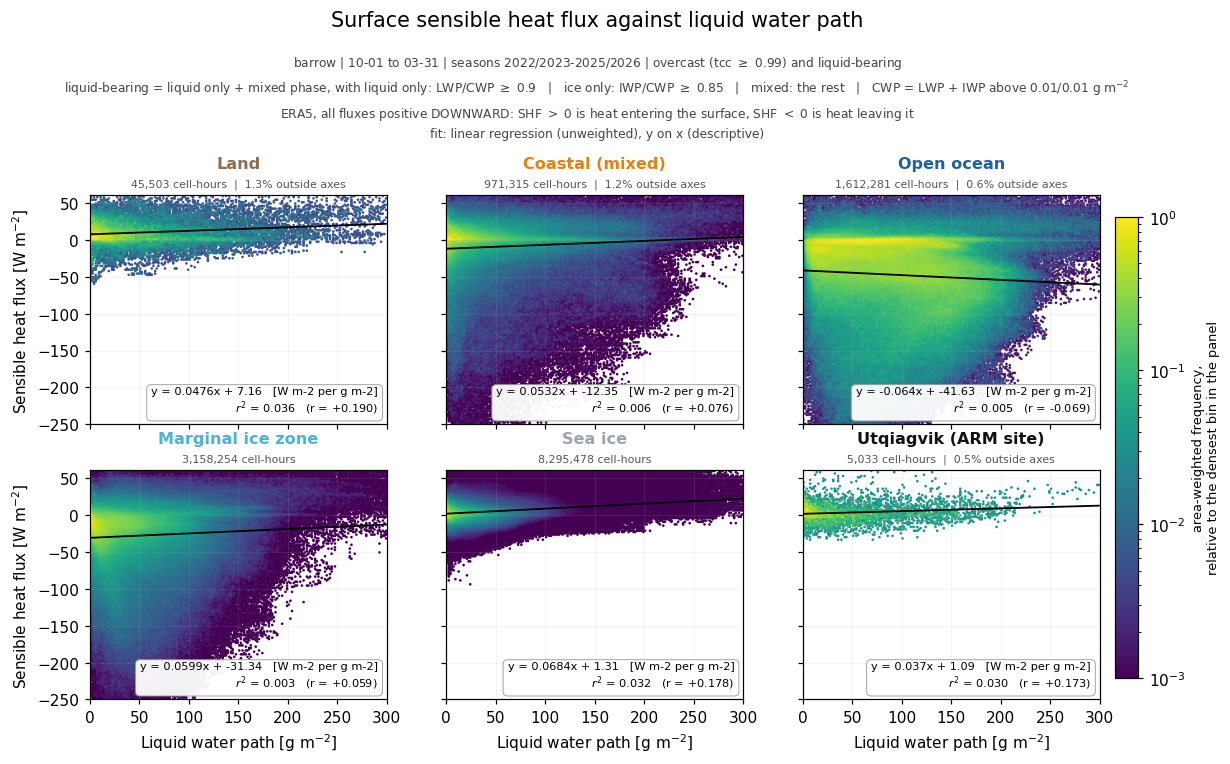

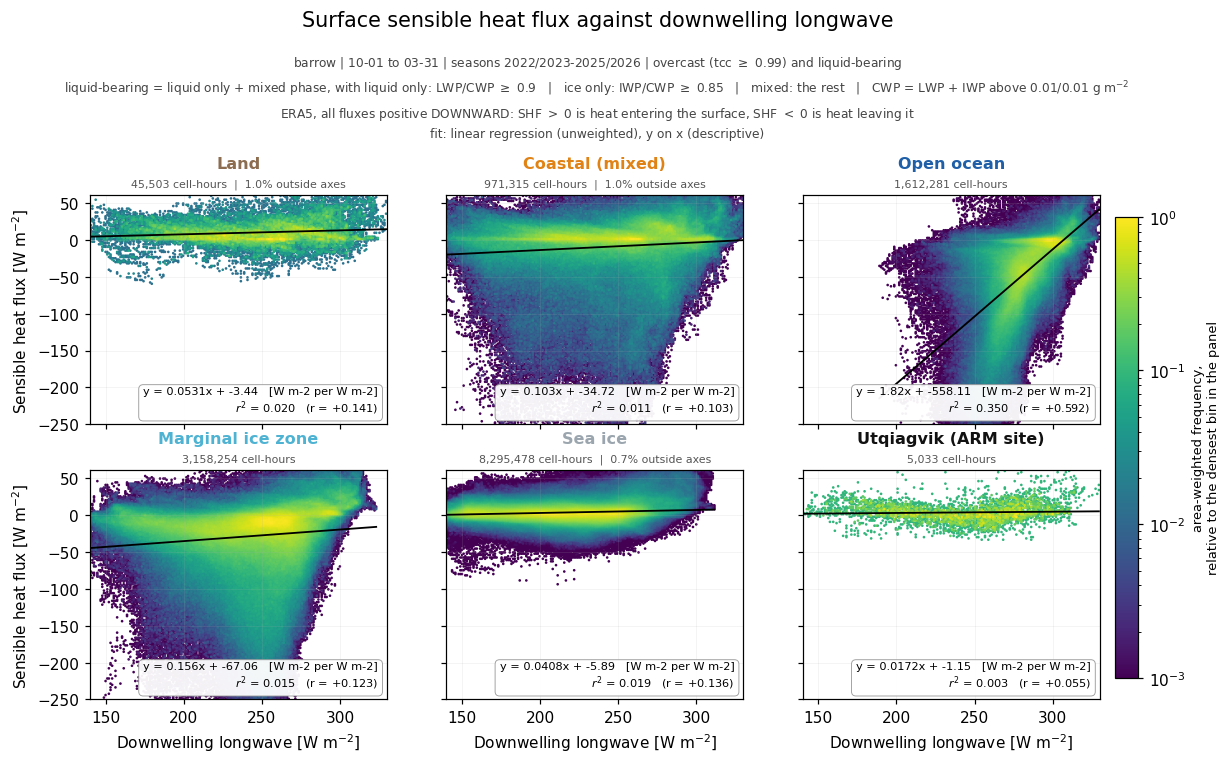

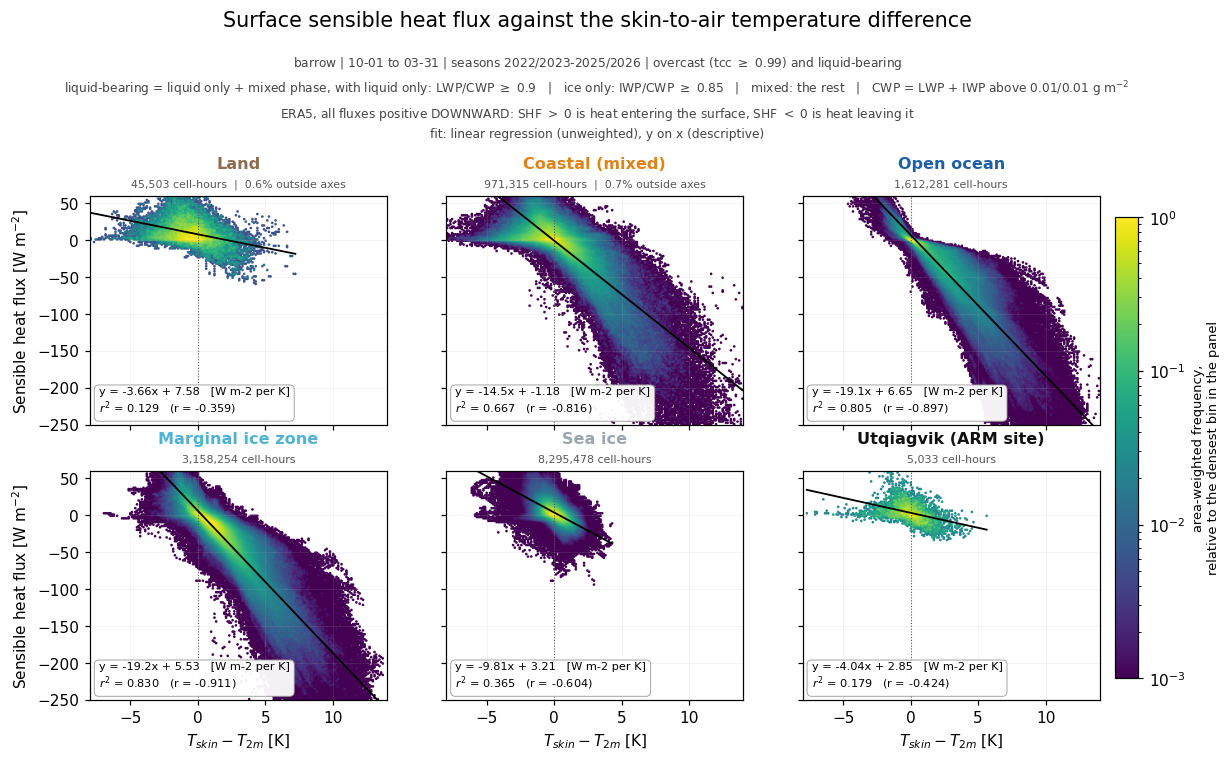

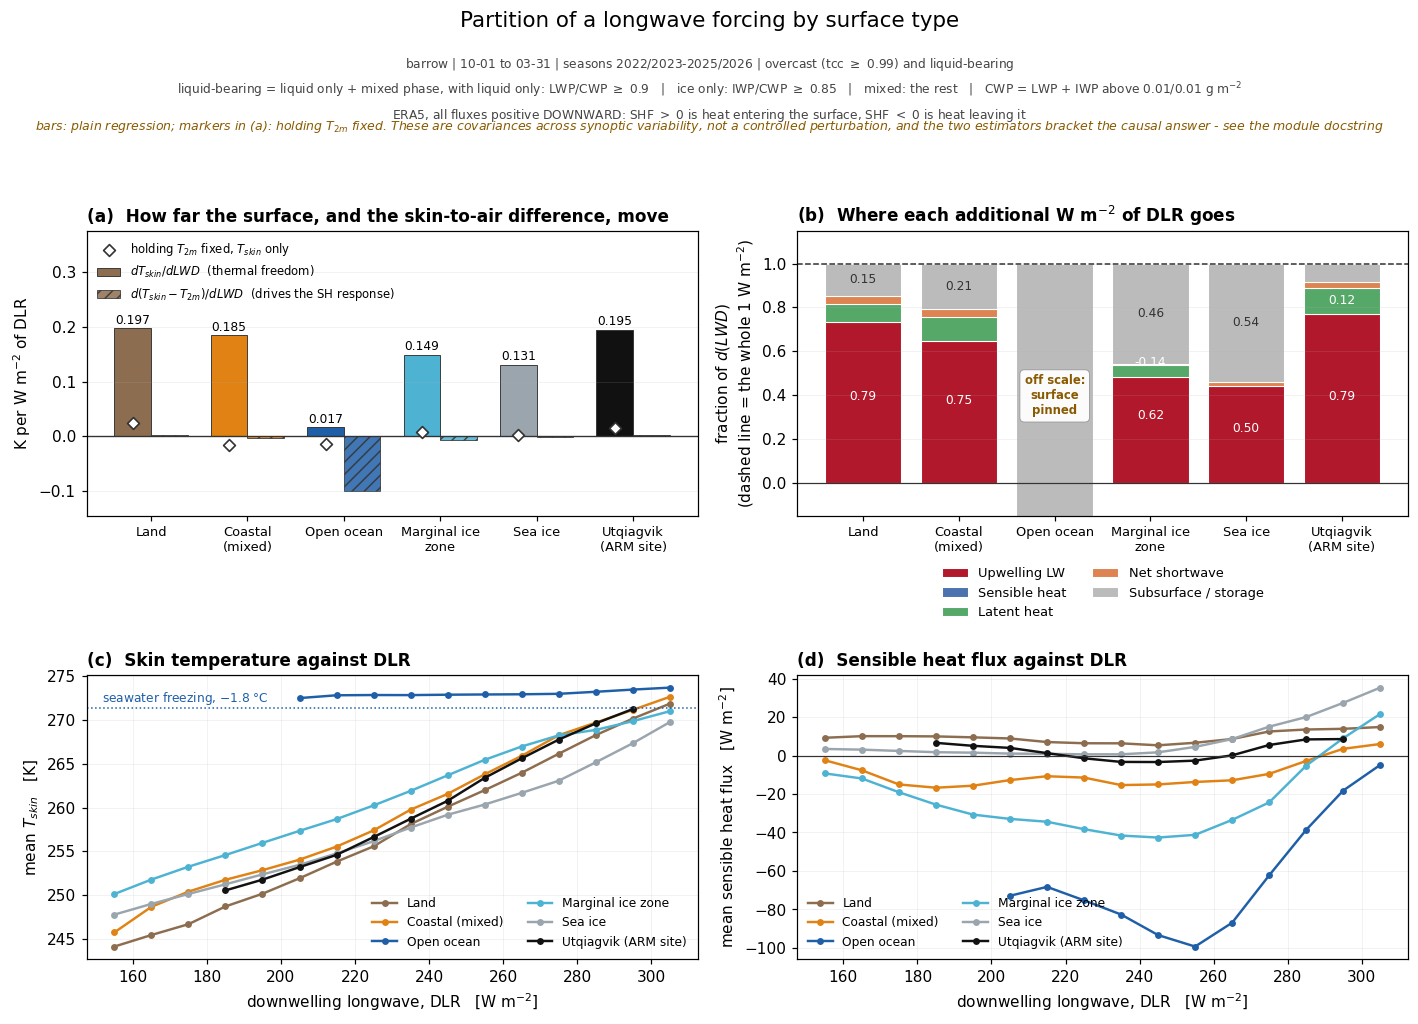

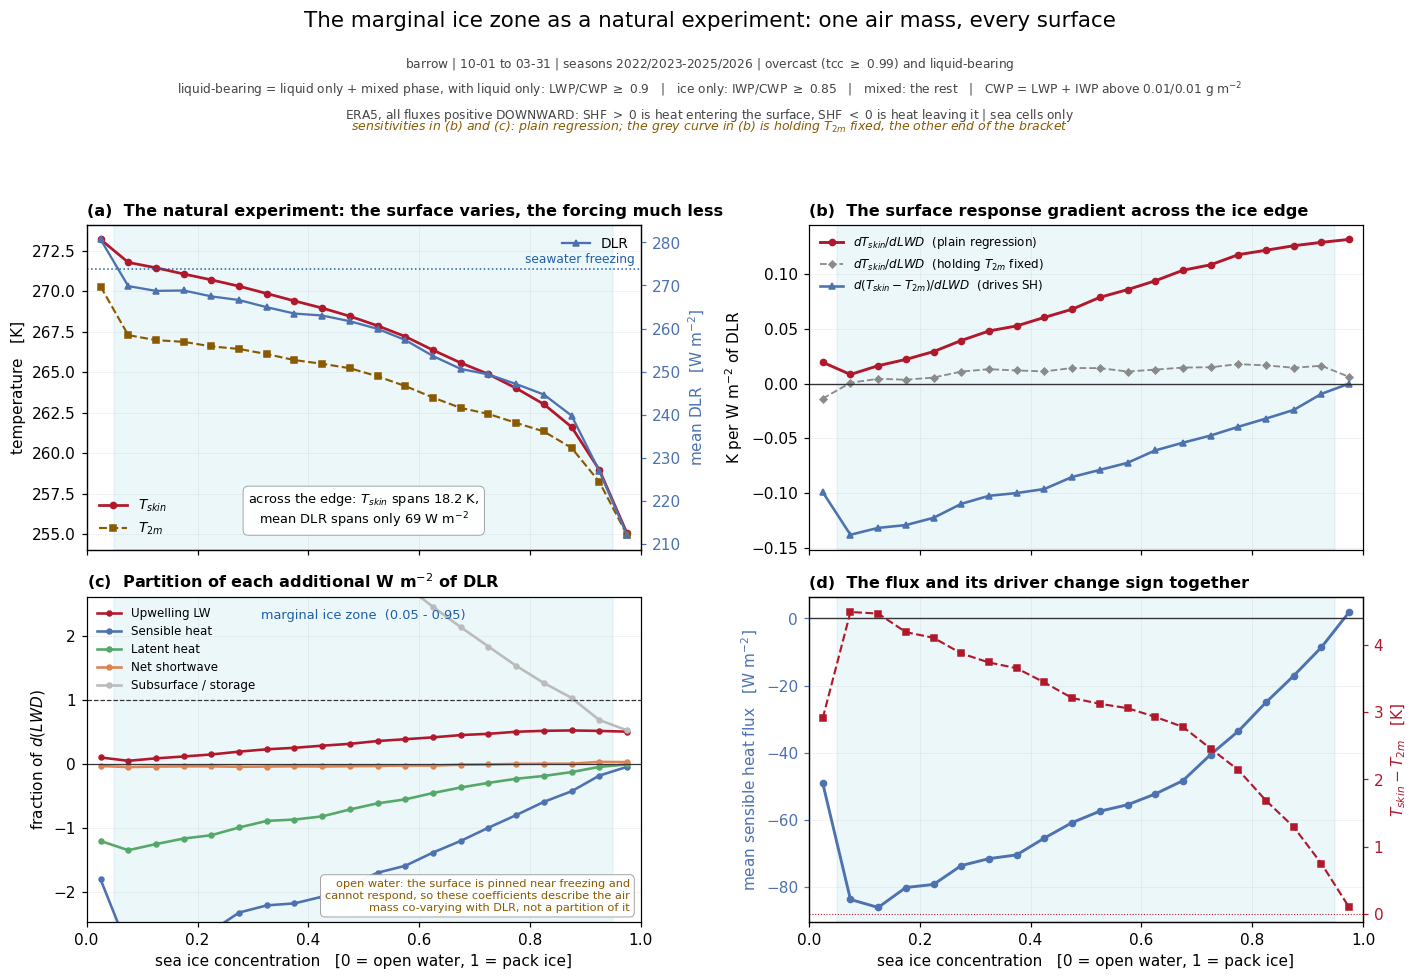

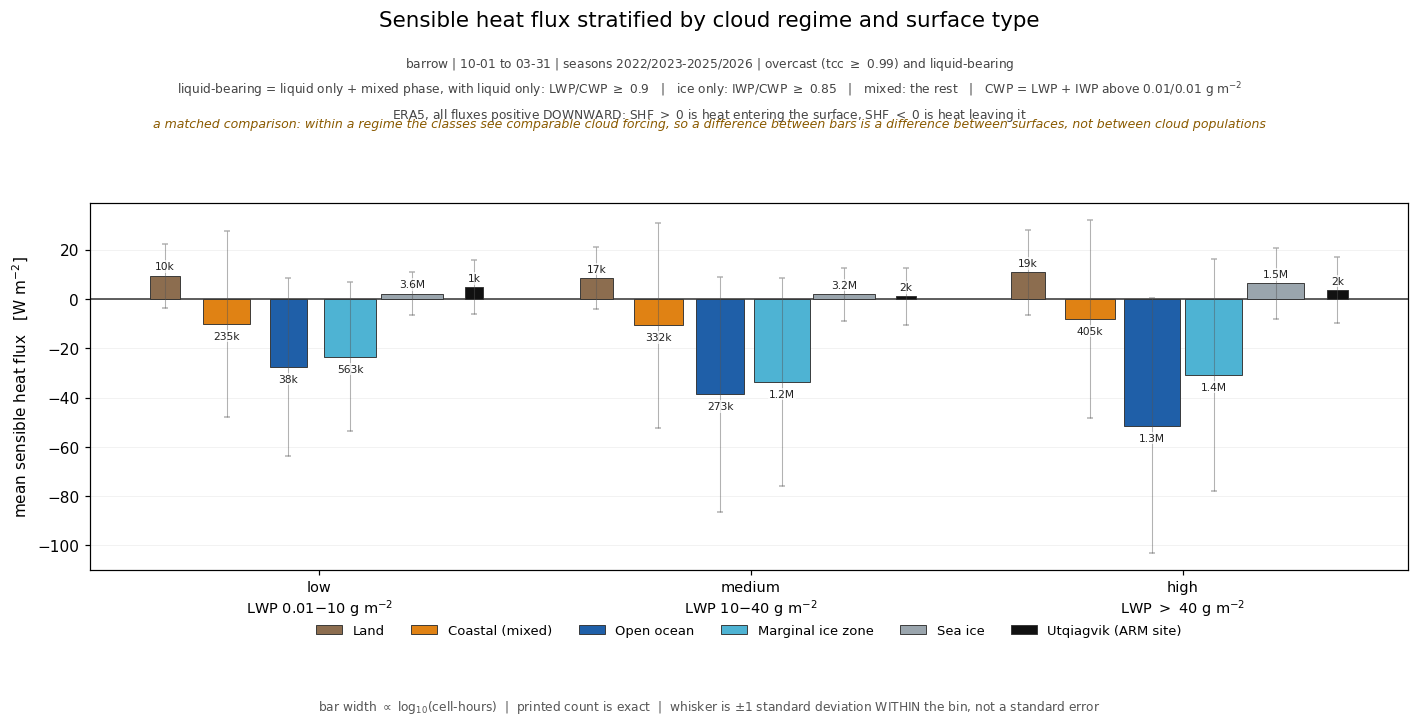

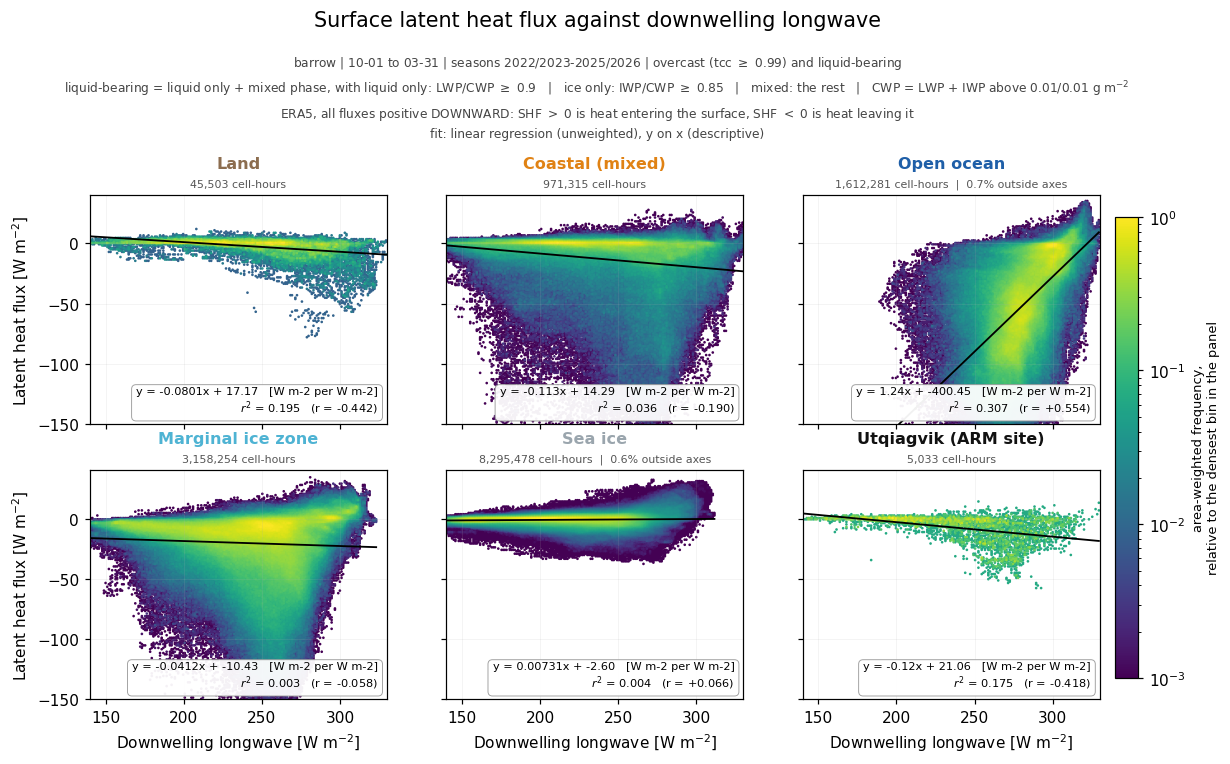

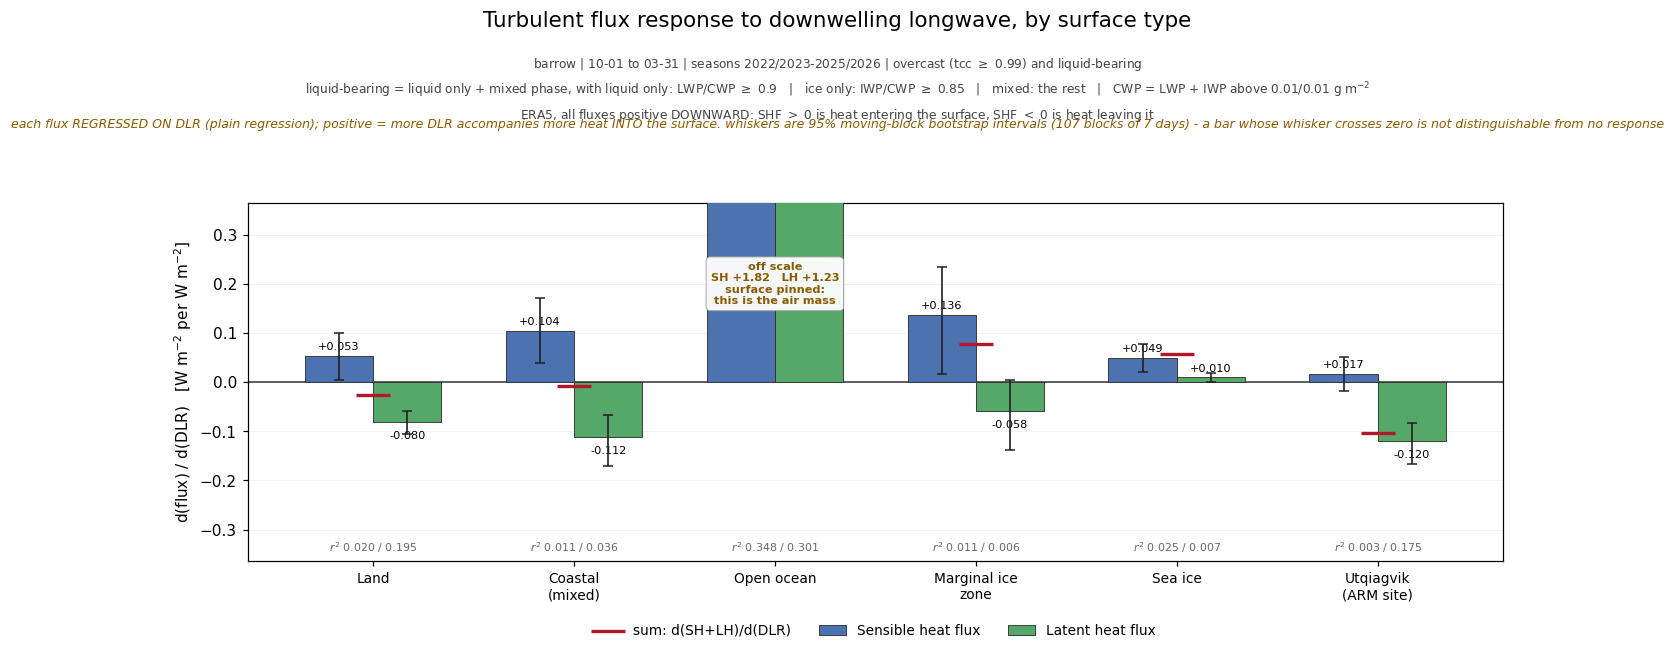

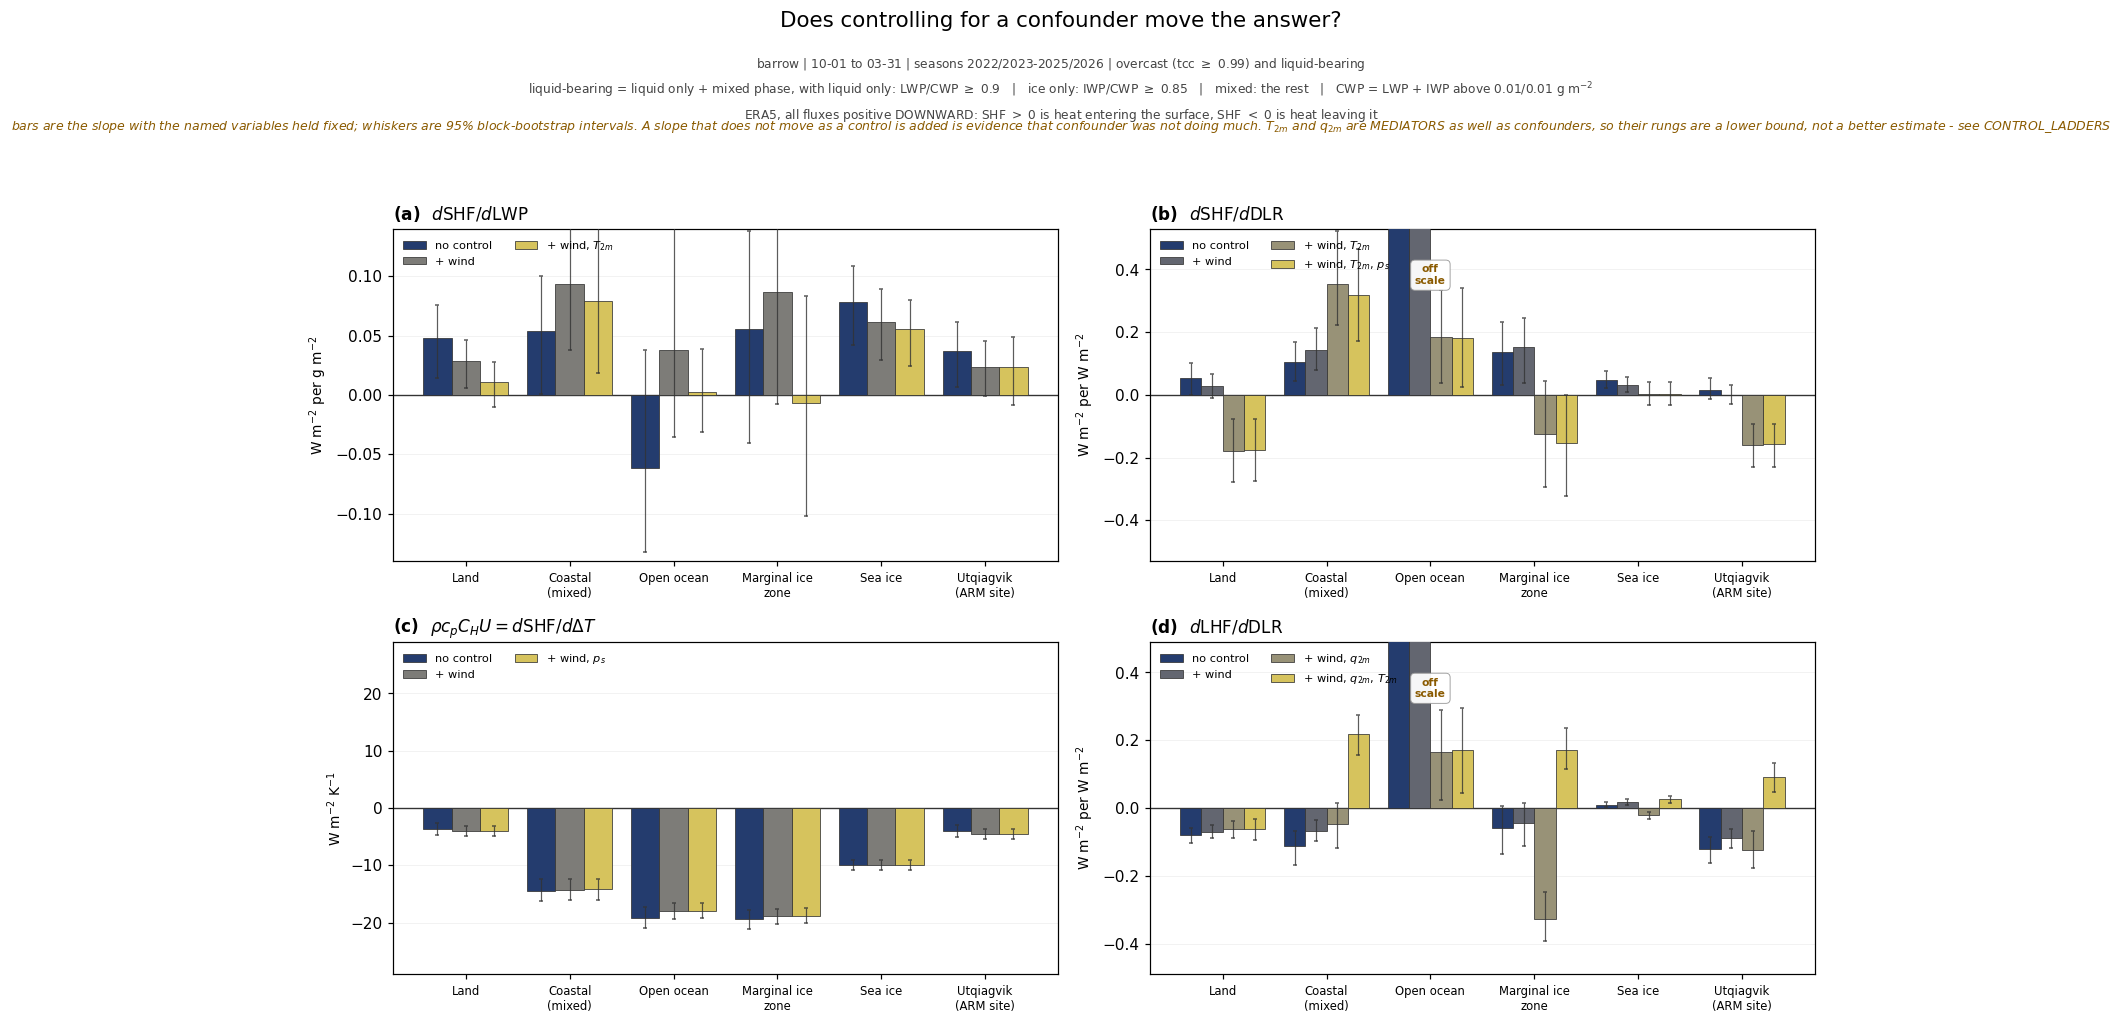

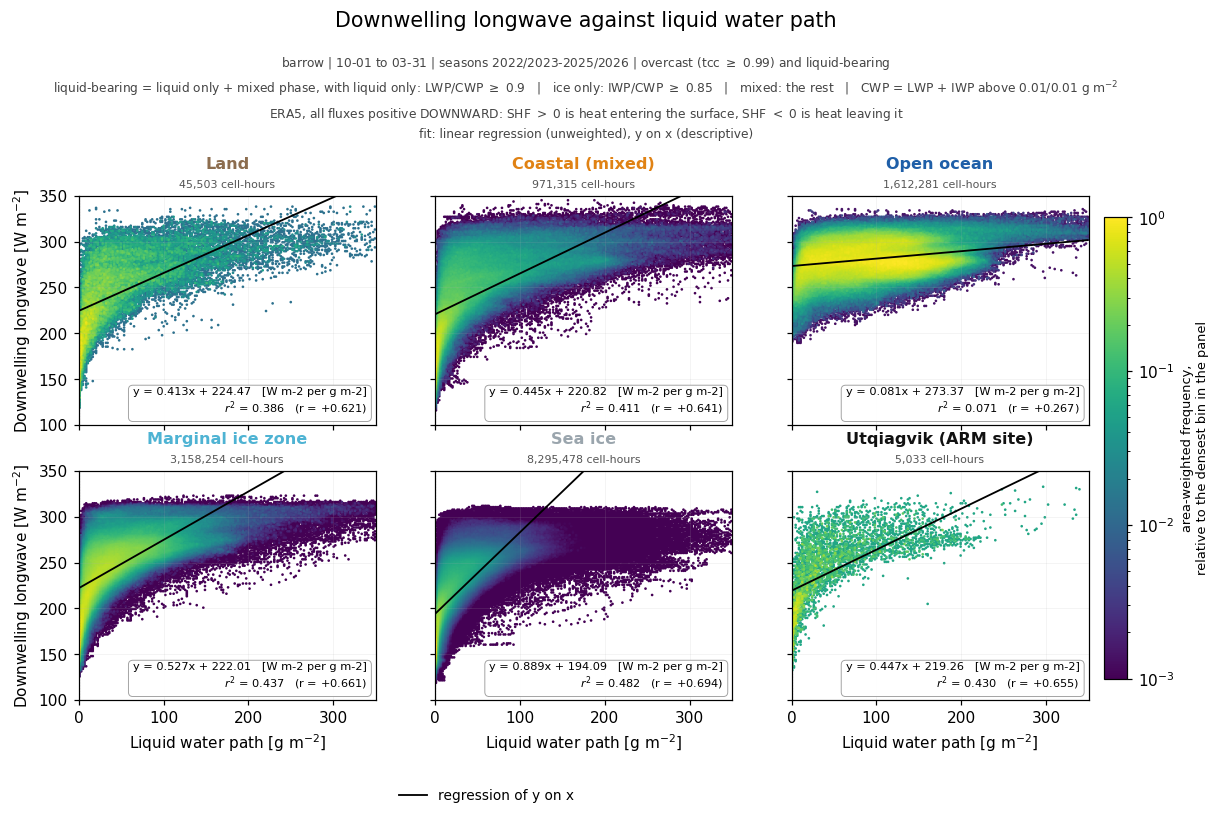

In [16]:
for fn in tfr.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR, dpi=DPI);

## Changing options

Anything that alters what is **loaded, classified or accumulated** — region,
years, season window, phase thresholds, cloud-cover gate — needs a fresh
`prepare()`, because the histograms and moments are filled during the streaming
pass:

```python
# a stricter liquid share, or a floor near a microwave radiometer's detection limit
A_strict = tfr.prepare(region="barrow", years=(2022, 2023),
                       phase_mode="fraction", liquid_fraction_min=0.95)
A_mwr = tfr.prepare(region="barrow", years=(2022, 2023),
                    phase_mode="fraction", min_lwp=25.0)

# back to the absolute g m-2 scheme, for comparison
A_abs = tfr.prepare(region="barrow", years=(2022, 2023),
                    phase_mode="absolute", liquid_lwp_min=5.0)

# midwinter only, precipitating scenes removed
A_djf = tfr.prepare(region="barrow", years=(2022, 2023),
                    season_start=(12, 1), season_end=(2, 28), no_precip=True)
```

Anything that only affects **which accumulated numbers a figure reads** can be
changed on the existing `A` with no reload, since both populations and every
control set were filled in the same pass:

```python
# swap the scatter overlay; both moment sets were accumulated in the same pass
tfr.fig_shf_vs_dlr(A, fit_mode="regression")   # thin black unweighted line
tfr.fig_shf_vs_dlr(A, fit_mode="default")      # red dashed weighted + binned mean

# swap which regression direction is drawn
tfr.fig_shf_vs_dskt(A, fit_orient="both")      # both lines, with the 1/r2 gap
tfr.fig_shf_vs_dskt(A, fit_orient="y_on_x")    # the descriptive fit

# the sensitivity figures for all-sky hours instead of liquid-bearing overcast
tfr.fig_response_partition(A, population="all")
tfr.fig_miz_transect(A, population="all")

# swap which estimator is the headline
tfr.fig_miz_transect(A, control="t2m")
tfr.fig_response_partition(A, control="t2m_wind")

# the report for the other population
tfr.print_report(A, population="all")
```

The three density scatters are accumulated for the liquid-bearing overcast
population only, and raise if asked for `population="all"` — the histograms are
the one thing that would need a second pass.

Individual numbers are available directly, without a figure:

```python
acc = A.acc()                       # class-slot moments, current population

# slope, intercept, r, r2, means; weighted=False for the unweighted regression
tfr.moment_stats(acc, tfr.CLASS_CODES["sea_ice"], "shf_W_m2", "lwd_W_m2")
tfr.moment_stats(acc, tfr.CLASS_CODES["sea_ice"], "shf_W_m2", "lwd_W_m2",
                 weighted=False)

# both directions at once, plus r2 and the 1/r2 inflation factor
f = tfr.fit_pair(acc, tfr.CLASS_CODES["sea_ice"], "shf_W_m2", "dskt_t2m_K")
coupling = -f["x_on_y"]["slope"]        # W m-2 K-1, the bulk coefficient
f["inflation"]                          # what inverting the other fit would cost
tfr.partition(acc, tfr.CLASS_CODES["marginal_ice"])
tfr.partial_slope(acc, tfr.SITE_SLOT, "skt_K", "lwd_W_m2", ("t2m_K",))
```